# Esophageal Cancer Research - Association Rule Mining
* By Sangwon Baek
* Samsung Medical Center
* September 6th, 2023

### Import necessary packages and read data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

from statsmodels.graphics.mosaicplot import mosaic
import itertools

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.options.mode.chained_assignment = None

In [2]:
df = pd.read_csv("../Data/Preprocessed/ECA_Dataset.csv").drop(columns="Unnamed: 0")

In [47]:
#Rename my columns
df.rename(columns={'pos_105/108/110': 'pos_105-108-110', 'total_105/108/110': 'total_105-108-110', 'pos_1/2/7':'pos_1-2-7', 'total_1/2/7':'total_1-2-7'}, inplace=True)

In [48]:
def N_categorize(x):
    if x == 0:
        return '0'
    elif 1 <= x <= 2:
        return '1'
    elif 3 <= x <= 6:
        return '2'
    else: # x > 7
        return '3'

# Listing the columns that start with "pos_" and "total_"
pos_columns = [col for col in df.columns if col.startswith("pos_")]
total_columns = [col for col in df.columns if col.startswith("total_")]
    
# Extract T, N, and M categories using regular expressions and then remove the prefixes
df['T_category'] = df['pTNM7_1'].str.extract('(TX|T0|Tis|T1a|T1b|T2|T3|T4a|T4b)').replace('T', '', regex=True)
df['N_category'] = df.total_pos_LN.apply(N_categorize)
df['M_category'] = df['pTNM7_1'].str.extract('(M0|M1)').replace('M', '', regex=True)

#Create the df with the whole dataset
Whole_df = df.copy() 

#Create the subgroup dfs for the subgroup analysis
Whole_upper_df = df.loc[df.Primary_Site=='upper']
Whole_mid_df = df.loc[df.Primary_Site=='mid']
Whole_lower_df = df.loc[df.Primary_Site=='lower']

# Filtering out 'is' category and creating the two groups
T1_df = df[df['T_category'].isin(['1a', '1b'])]
T24_df = df[df['T_category'].isin(['2', '3', '4a', '4b'])]
T2_df = df[df['T_category'].isin(['2'])]
T3_df = df[df['T_category'].isin(['3'])]
T4_df = df[df['T_category'].isin(['4a', '4b'])]

#Create the subgroup dfs for the subgroup analysis
T1_upper_df = T1_df.loc[T1_df.Primary_Site=='upper']
T1_mid_df = T1_df.loc[T1_df.Primary_Site=='mid']
T1_lower_df = T1_df.loc[T1_df.Primary_Site=='lower']

T24_upper_df = T24_df.loc[T24_df.Primary_Site=='upper']
T24_mid_df = T24_df.loc[T24_df.Primary_Site=='mid']
T24_lower_df = T24_df.loc[T24_df.Primary_Site=='lower']

T2_upper_df = T2_df.loc[T2_df.Primary_Site=='upper']
T2_mid_df = T2_df.loc[T2_df.Primary_Site=='mid']
T2_lower_df = T2_df.loc[T2_df.Primary_Site=='lower']

T3_upper_df = T3_df.loc[T3_df.Primary_Site=='upper']
T3_mid_df = T3_df.loc[T3_df.Primary_Site=='mid']
T3_lower_df = T3_df.loc[T3_df.Primary_Site=='lower']

T4_upper_df = T4_df.loc[T4_df.Primary_Site=='upper']
T4_mid_df = T4_df.loc[T4_df.Primary_Site=='mid']
T4_lower_df = T4_df.loc[T4_df.Primary_Site=='lower']

In [49]:
#Describe the datsets 
dataset_descriptors = ["Whole", "Whole_upper", "Whole_mid", "Whole_lower", 
                       "T1", "T1_upper", "T1_mid", "T1_lower", 
                       "T24", "T24_upper", "T24_mid", "T24_lower",
                       "T2", "T2_upper", "T2_mid", "T2_lower",
                       "T3", "T3_upper", "T3_mid", "T3_lower",
                       "T4", "T4_upper", "T4_mid", "T4_lower"]

#Define the numbers and N_categories I want to test 
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 44]
N_categories = ['0','1','2','3']

#Predefined order of the lymphnodes
predefined_order = ['101R', '101L', '102R', '102L', '104R', '104L', '106preR', '106preL', '106recR', 
                    '106recL', '107', '105-108-110', '112pulR', '112pulL', '1-2-7', '8', '9']

# Use the function
dfs = [
    ("Whole", Whole_df), 
    ("Whole Upper", Whole_upper_df), 
    ("Whole Mid", Whole_mid_df), 
    ("Whole Lower", Whole_lower_df), 
    ("T1", T1_df), 
    ("T1 upper", T1_upper_df), 
    ("T1 mid", T1_mid_df), 
    ("T1 lower", T1_lower_df), 
    ("T2", T2_df), 
    ("T2 upper", T2_upper_df), 
    ("T2 mid", T2_mid_df), 
    ("T2 lower", T2_lower_df), 
    ("T3", T3_df), 
    ("T3 upper", T3_upper_df), 
    ("T3 mid", T3_mid_df), 
    ("T3 lower", T3_lower_df), 
    ("T4", T4_df), 
    ("T4 upper", T4_upper_df), 
    ("T4 mid", T4_mid_df), 
    ("T4 lower", T4_lower_df), 
    ("T24", T24_df), 
    ("T24 upper", T24_upper_df),
    ("T24 mid", T24_mid_df),
    ("T24 lower", T24_lower_df)
]

In [50]:
def patient_counts(*dataframes):
    # Create a dictionary with conditions as keys to store results
    counts_dict = { "Data Type": [] }
    for i in range(1, 20):
        counts_dict[f"upto {i}"] = []

    # Define the conditions
    conditions = [f"upto {i}" for i in range(1, 20)]

    # Loop through each dataframe and calculate counts
    for df_name, df in dataframes:
        counts_dict["Data Type"].append(df_name)
        for cond in conditions:
            limit = int(cond.split(" ")[1])  # Extracting the number from the condition string
            value = len(df.loc[(df.total_pos_LN >= 1) & (df.total_pos_LN <= limit)])
            counts_dict[cond].append(value)

    # Convert the dictionary to a DataFrame and return
    return pd.DataFrame(counts_dict)

def patient_counts_by_category(*dataframes):
    # Create a dictionary with conditions as keys to store results
    counts_dict = {"Data Type": []}

    # Extract all unique N_category values from the dataframes
    all_categories = set()
    for _, df in dataframes:
        all_categories.update(df['N_category'].unique())
    all_categories = sorted(list(all_categories))

    # Initialize counts_dict with all_categories as keys
    for cat in all_categories:
        counts_dict[cat] = []

    # Loop through each dataframe and calculate counts
    for df_name, df in dataframes:
        counts_dict["Data Type"].append(df_name)
        for cat in all_categories:
            value = len(df[df['N_category'] == cat])
            counts_dict[cat].append(value)

    # Convert the dictionary to a DataFrame and return
    return pd.DataFrame(counts_dict)

In [51]:
result_df = patient_counts(*dfs)
result_df.to_csv("../Results/data_lengths.csv")
result_df

,Data Type,upto 1,upto 2,upto 3,upto 4,upto 5,upto 6,upto 7,upto 8,upto 9,upto 10,upto 11,upto 12,upto 13,upto 14,upto 15,upto 16,upto 17,upto 18,upto 19
0,Whole,416,655,816,923,985,1023,1058,1082,1096,1112,1127,1136,1142,1146,1156,1158,1162,1165,1168
1,Whole Upper,47,70,89,101,108,113,116,116,120,124,124,125,125,125,126,126,128,129,129
2,Whole Mid,210,325,400,453,481,499,512,524,526,533,539,545,548,551,556,557,557,557,557
3,Whole Lower,159,260,327,369,395,410,429,441,449,454,463,465,468,469,473,474,476,478,481
4,T1,213,295,340,364,376,379,381,385,386,388,390,391,391,391,391,391,391,391,391
5,T1 upper,27,38,43,45,46,46,46,46,46,47,47,47,47,47,47,47,47,47,47
6,T1 mid,110,146,169,181,187,188,189,191,191,191,192,193,193,193,193,193,193,193,193
7,T1 lower,76,111,128,138,143,145,146,148,149,150,151,151,151,151,151,151,151,151,151
8,T2,72,112,141,158,166,171,176,180,181,182,186,188,190,190,191,192,192,193,193
9,T2 upper,6,9,13,17,18,18,19,19,20,21,21,21,21,21,22,22,22,23,23


In [52]:
result2_df = patient_counts_by_category(*dfs)
result2_df.to_csv("../Results/N_category_lengths.csv")
result2_df

,Data Type,0,1,2,3
0,Whole,1482,655,368,158
1,Whole Upper,143,70,43,16
2,Whole Mid,776,325,174,67
3,Whole Lower,563,260,150,75
4,T1,1076,295,84,12
5,T1 upper,97,38,8,1
6,T1 mid,563,146,42,5
7,T1 lower,416,111,34,6
8,T2,156,112,59,24
9,T2 upper,17,9,9,5


### Association Rule Mining PS

In [53]:
def transaction_encoder(transactions):
    te = TransactionEncoder()
    oht = te.fit_transform(transactions)
    df_oht = pd.DataFrame(oht, columns=te.columns_)
    return df_oht

# Function to save dataframes to multiple sheets
def save_to_excel(filename, dataframes):
    with pd.ExcelWriter(filename) as writer:
        for name, df in dataframes:
            df.to_excel(writer, sheet_name=name)

In [54]:
def convert_to_lymph_transactions_PS(df):
    transactions = []

    # Getting all columns related to positive lymph node stations
    pos_columns = [col for col in df.columns if col.startswith('pos_')]

    # Excluding the specified columns from the lymph node stations
    excluded_columns = ["pos_neckLN", "pos_mediaLN", "pos_abdoLN", 
                        "pos_neckLN_new", "pos_mediaLN_new", "pos_abdoLN_new", 
                        "pos_ON", "pos_OM", "pos_OA"]
    specific_pos_columns = [col for col in pos_columns if col not in excluded_columns]

    for index, row in df.iterrows():        
        # Extracting the specific lymph node stations with positive counts (removing "pos_" prefix)
        nodes = [col[4:] for col in specific_pos_columns if pd.to_numeric(row[col], errors='coerce') > 0]
        
        # Including the primary site in the transaction
        transaction = [str(row['Primary_Site'])] + [str(item) for item in nodes if item is not None]
        
        if len(transaction) >= 2:  # Only consider transactions with at least a primary site and one lymph node
            transactions.append(transaction)
        
    return transactions

def association_rule_mining_PS(df, count, category, min_support, min_confidence, filterCount):
    if count == None:
        df_temp = df[df['N_category'] == category]
    if category == None:
        df_temp = df[df['total_pos_LN'] <= count]
    
    # Convert the dataset into lymph node transactions format
    lymph_transactions = convert_to_lymph_transactions_PS(df_temp)

    # Convert to transaction encoder df
    transaction_df = transaction_encoder(lymph_transactions)
    
    # Run fpgrowth
    frequent_itemsets = fpgrowth(transaction_df, min_support=min_support, use_colnames=True).sort_values(by='support', ascending=False)

    # Identify association rules
    try:
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence).sort_values(by="support", ascending=False)
        
        # Check if any rules were found
        if rules.empty:
            if count==None:
                print(f"No frequent itemsets found for N_category: {category}")
            if category==None:
                print(f"No frequent itemsets found for count: {count}")
            return pd.DataFrame()

        # Ensure primary sites ('lower', 'mid', 'upper') are only in the antecedents
        # and specific lymphnode locations are only in the consequents
        primary_sites = ['lower', 'mid', 'upper']
        rules = rules[rules['antecedents'].apply(lambda x: list(x)[0] in primary_sites)]
        rules = rules[rules['consequents'].apply(lambda x: list(x)[0] not in primary_sites)]
        # (rules['antecedents'].apply(lambda x: len(x) == 1)) & 
        # Filter rules with only one item in the antecedent and consequent
        if filterCount == 1:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 1)) & (rules['consequents'].apply(lambda x: len(x) == 1))]
        elif filterCount == 2:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 1)) & (~rules['consequents'].apply(lambda x: len(x) == 1))]

        # Convert antecedents and consequents from frozenset to string
        rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

        # Calculate the actual count of each rule
        rules['count'] = rules['support'] * len(lymph_transactions)

        # # Filter out rows where 'count' is equal to 1
        # rules = rules[rules['count'] != 1]
        
        # Include selected columns
        IncludeColumns = ['antecedents', 'consequents', 'count', 'support', 'confidence', 'lift'] 
        associationRule = rules[IncludeColumns]
        
        return associationRule

    except Exception as e:
        if count==None:
            print(f"Error for N_category {category}: {e}")
        if category==None:
            print(f"Error for count {count}: {e}")
        return pd.DataFrame()

def combine_association_rules_PS(descriptor):
    numbers = ['N1', 'N2', 'N3', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_association_rules_PS_2(descriptor):
    numbers = ['N1', 'N2', 'N3', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_PS_N_category(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_PS_N_category_2(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

In [55]:
for descriptor in dataset_descriptors:
    for num in numbers:
        label = 'all' if num == 44 else str(num)
        globals()[f"associationRule_PS_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], num, None, 0.001, 0.001, 1)
        globals()[f"associationRule_PS_2_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], num, None, 0.001, 0.001, 2)

Error for count 1: The input DataFrame `df` containing the frequent itemsets is empty.
Error for count 1: The input DataFrame `df` containing the frequent itemsets is empty.


In [56]:
#Get association rule based on N_Category
for descriptor in dataset_descriptors:
    for category in N_categories:
        label = f'N{category}'
        globals()[f"associationRule_PS_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], None, category, 0.001, 0.001, 1)
        globals()[f"associationRule_PS_2_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], None, category, 0.001, 0.001, 2)

Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemset

In [57]:
# 1. Combine datasets using loops and dictionaries
sections_PS = ['Whole', 'T1', 'T24', 'T2', 'T3', 'T4']
subsections_PS = ['', '_upper', '_mid', '_lower']

combined_data_PS = {}
combined_data_PS_N = {}

for section in sections_PS:
    for sub in subsections_PS:
        key = f"combined_PS_{section}{sub}"
        combined_data_PS[key] = combine_association_rules_PS(f"{section}{sub}")
        combined_data_PS_N[key] = combine_AR_PS_N_category(f"{section}{sub}")

# 2. Create the association_rules_PS_dfs list from the dictionary
association_rules_PS_dfs = [(key.replace("combined_PS_", ""), combined_data_PS[key]) for key in combined_data_PS]
association_rules_PS_N_dfs = [(key.replace("combined_PS_", ""), combined_data_PS_N[key]) for key in combined_data_PS_N]

# Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_PS.xlsx', association_rules_PS_dfs)
save_to_excel('../Results/association_rules_PS_Ncategory.xlsx', association_rules_PS_N_dfs)

In [58]:
combined_data_PS_2 = {}
combined_data_PS_2_N = {}

for section in sections_PS:
    for sub in subsections_PS:
        key = f"combined_PS_{section}{sub}"
        combined_data_PS_2[key] = combine_association_rules_PS_2(f"{section}{sub}")
        combined_data_PS_2_N[key] = combine_AR_PS_N_category_2(f"{section}{sub}")

# 2. Create the association_rules_PS_dfs list from the dictionary
association_rules_PS_2_dfs = [(key.replace("combined_PS_", ""), combined_data_PS_2[key]) for key in combined_data_PS_2]
association_rules_PS_2_N_dfs = [(key.replace("combined_PS_", ""), combined_data_PS_2_N[key]) for key in combined_data_PS_2_N]

# Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_PS_2.xlsx', association_rules_PS_2_dfs)
save_to_excel('../Results/association_rules_PS_Ncategory_2.xlsx', association_rules_PS_2_N_dfs)

### Modify the existing function from the mlxtend library to serve my purpose

In [59]:
def custom_association_rules(df, metric="confidence", min_threshold=0.8, support_only=False):
    
    if not df.shape[0]:
        raise ValueError(
            "The input DataFrame `df` containing " "the frequent itemsets is empty."
        )

    # check for mandatory columns
    if not all(col in df.columns for col in ["support", "itemsets"]):
        raise ValueError(
            "Dataframe needs to contain the\
                         columns 'support' and 'itemsets'"
        )

    def conviction_helper(sAC, sA, sC):
        confidence = sAC / sA
        conviction = np.empty(confidence.shape, dtype=float)
        if not len(conviction.shape):
            conviction = conviction[np.newaxis]
            confidence = confidence[np.newaxis]
            sAC = sAC[np.newaxis]
            sA = sA[np.newaxis]
            sC = sC[np.newaxis]
        conviction[:] = np.inf
        conviction[confidence < 1.0] = (1.0 - sC[confidence < 1.0]) / (
            1.0 - confidence[confidence < 1.0]
        )

        return conviction
    
#     def zhangs_metric_helper(sAC, sA, sC):
#         denominator = np.maximum(sAC * (1 - sA), sA * (sC - sAC))
#         numerator = metric_dict["leverage"](sAC, sA, sC)

#         with np.errstate(divide="ignore", invalid="ignore"):
#             # ignoring the divide by 0 warning since it is addressed in the below np.where
#             zhangs_metric = np.where(denominator == 0, 0, numerator / denominator)

#         return zhangs_metric
    
    def zhangs_metric_helper(sAC, sA, sC):
        confidence_A_C = sAC / sA
        confidence_not_A_C = (sC - sAC) / (1 - sA)

        numerator = confidence_A_C - confidence_not_A_C
        denominator = np.maximum(confidence_A_C, confidence_not_A_C)

        with np.errstate(divide="ignore", invalid="ignore"):
            # ignoring the divide by 0 warning since it is addressed in the below np.where
            zhangs_metric = np.where(denominator == 0, 0, numerator / denominator)

        return zhangs_metric
    
    def net_confidence_helper(sAC, sA, sC):
        confidence_A_C = sAC / sA
        confidence_not_A_C = (sC - sAC) / (1 - sA)
        net_confidence = confidence_A_C-confidence_not_A_C
        return net_confidence

    # def net_confidence_helper(sAC, sA, sC):
    #     return (sAC - (sA * sC)) / (sA * (1 - sA))

    def attributable_confidence_helper(sAC, sA, sC):
        confidence_A_C = sAC / sA
        confidence_not_A_C = (sC - sAC) / (1 - sA)
        attributable_confidence = (confidence_A_C-confidence_not_A_C)/confidence_A_C 
        return attributable_confidence

    def interestingness_helper(sAC, sA, sC):
        return (sAC / sA) * (sAC / sC) * (1 - sAC)

    def certain_factor_helper(sAC, sA, sC):
        return (sAC/sA - sC) / (1 - sC)

    def comprehensibility_helper(sAC, sA, sC):
        return (np.log(1 + sA)) / (np.log(1 + sAC))
    
    # metrics for association rules
    metric_dict = {
        "antecedent support": lambda _, sA, __: sA,
        "consequent support": lambda _, __, sC: sC,
        "support": lambda sAC, _, __: sAC,
        "confidence": lambda sAC, sA, _: sAC / sA,
        "lift": lambda sAC, sA, sC: metric_dict["confidence"](sAC, sA, sC) / sC,
        "leverage": lambda sAC, sA, sC: metric_dict["support"](sAC, sA, sC) - sA * sC,
        "conviction": lambda sAC, sA, sC: conviction_helper(sAC, sA, sC),
        "zhangs_metric": lambda sAC, sA, sC: zhangs_metric_helper(sAC, sA, sC),
        "interestingness": lambda sAC, sA, sC: interestingness_helper(sAC, sA, sC),
        "net confidence": lambda sAC, sA, sC: net_confidence_helper(sAC, sA, sC),
        "attributable confidence": lambda sAC, sA, sC: attributable_confidence_helper(sAC, sA, sC),
        "certain factor": lambda sAC, sA, sC: certain_factor_helper(sAC, sA, sC),
        "comprehensibility": lambda sAC, sA, sC: comprehensibility_helper(sAC, sA, sC)
    }

    columns_ordered = [
        "antecedent support",
        "consequent support",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction",
        "zhangs_metric",
        "net confidence",
        "attributable confidence",
        "interestingness",
        "certain factor",
        "comprehensibility"
    ]

    # check for metric compliance
    if support_only:
        metric = "support"
    else:
        if metric not in metric_dict.keys():
            raise ValueError(
                "Metric must be 'confidence' or 'lift', got '{}'".format(metric)
            )

    # get dict of {frequent itemset} -> support
    keys = df["itemsets"].values
    values = df["support"].values
    frozenset_vect = np.vectorize(lambda x: frozenset(x))
    frequent_items_dict = dict(zip(frozenset_vect(keys), values))

    # prepare buckets to collect frequent rules
    rule_antecedents = []
    rule_consequents = []
    rule_supports = []

    # iterate over all frequent itemsets
    for k in frequent_items_dict.keys():
        sAC = frequent_items_dict[k]
        # to find all possible combinations
        for idx in range(len(k) - 1, 0, -1):
            # of antecedent and consequent
            for c in combinations(k, r=idx):
                antecedent = frozenset(c)
                consequent = k.difference(antecedent)

                if support_only:
                    # support doesn't need these,
                    # hence, placeholders should suffice
                    sA = None
                    sC = None

                else:
                    try:
                        sA = frequent_items_dict[antecedent]
                        sC = frequent_items_dict[consequent]
                    except KeyError as e:
                        s = (
                            str(e) + "You are likely getting this error"
                            " because the DataFrame is missing "
                            " antecedent and/or consequent "
                            " information."
                            " You can try using the "
                            " `support_only=True` option"
                        )
                        raise KeyError(s)
                    # check for the threshold

                score = metric_dict[metric](sAC, sA, sC)
                if score >= min_threshold:
                    rule_antecedents.append(antecedent)
                    rule_consequents.append(consequent)
                    rule_supports.append([sAC, sA, sC])

    # check if frequent rule was generated
    if not rule_supports:
        return pd.DataFrame(columns=["antecedents", "consequents"] + columns_ordered)

    else:
        # generate metrics
        rule_supports = np.array(rule_supports).T.astype(float)
        df_res = pd.DataFrame(
            data=list(zip(rule_antecedents, rule_consequents)),
            columns=["antecedents", "consequents"],
        )

        if support_only:
            sAC = rule_supports[0]
            for m in columns_ordered:
                df_res[m] = np.nan
            df_res["support"] = sAC

        else:
            sAC = rule_supports[0]
            sA = rule_supports[1]
            sC = rule_supports[2]
            for m in columns_ordered:
                df_res[m] = metric_dict[m](sAC, sA, sC)

        return df_res

### Association Rule Mining TN

In [60]:
def convert_to_lymph_transactions(df):
    transactions = []

    # Getting all columns related to positive lymph node stations
    pos_columns = [col for col in df.columns if col.startswith('pos_')]

    # Excluding the specified columns from the lymph node stations
    excluded_columns = ["pos_neckLN", "pos_mediaLN", "pos_abdoLN", 
                        "pos_neckLN_new", "pos_mediaLN_new", "pos_abdoLN_new", 
                        "pos_ON", "pos_OM", "pos_OA"]
    specific_pos_columns = [col for col in pos_columns if col not in excluded_columns]

    for index, row in df.iterrows():        
        # Extracting the specific lymph node stations with positive counts (removing "pos_" prefix)
        nodes = [col[4:] for col in specific_pos_columns if pd.to_numeric(row[col], errors='coerce') > 0]
        
        # Ensuring all items are strings
        transaction = [str(item) for item in nodes if item is not None]
        if len(transaction) >= 1:  # Only consider transactions with at least two lymph nodes
            transactions.append(transaction)
        
    return transactions

def association_rule_mining_TN(df, count, category, min_support, min_confidence, filterCount):
    if count == None:
        df_temp = df[df['N_category'] == category]
    if category == None:
        df_temp = df[df['total_pos_LN'] <= count]

    # Convert the dataset into lymph node transactions format
    lymph_transactions = convert_to_lymph_transactions(df_temp)

    # Convert to transaction encoder df
    transaction_df = transaction_encoder(lymph_transactions)
    
    # Run fpgrowth
    frequent_itemsets = fpgrowth(transaction_df, min_support=min_support, use_colnames=True).sort_values(by='support', ascending=False)

    # Identify association rules
    try:
        rules = custom_association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence).sort_values(by="support", ascending=False).sort_values(by="lift", ascending=False)
        
        # Check if any rules were found
        if rules.empty:
            if count==None:
                print(f"No frequent itemsets found for N_category: {category}")
            if category==None:
                print(f"No frequent itemsets found for count: {count}")
            return pd.DataFrame()
        
        # Filter rules with only one item in the antecedent and consequent
        if filterCount == 1:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 1)) & (rules['consequents'].apply(lambda x: len(x) == 1))]
        elif filterCount == 2:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 2)) | (rules['consequents'].apply(lambda x: len(x) == 2))]
        elif filterCount == 3:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 3)) | (rules['consequents'].apply(lambda x: len(x) == 3))]
        
        # Convert antecedents and consequents from frozenset to string
        rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

        # Calculate the actual count of each rule
        rules['count'] = rules['support'] * len(lymph_transactions)

        # Filter out rows where 'count' is equal to 1
        # rules = rules[rules['count'] != 1]
        
        # Include selected columns
        # IncludeColumns = ['antecedents', 'consequents', 'count', 'support', 'confidence', 'lift'] 
        # associationRule = rules[IncludeColumns]
        associationRule = rules

        return associationRule

    except Exception as e:
        if count==None:
            print(f"Error for N_category {category}: {e}")
        if category==None:
            print(f"Error for count {count}: {e}")
        return pd.DataFrame()

def combine_association_rules(descriptor):
    numbers = ['N1', 'N2', 'N3', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_TN_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_association_rules_2(descriptor):
    numbers = ['N1', 'N2', 'N3', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_TN_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_TN_N_Category(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_TN_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_TN_N_Category_2(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_TN_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

In [61]:
#Get association rule based on Counts
for descriptor in dataset_descriptors:
    for num in numbers:
        label = 'all' if num == 44 else str(num)
        globals()[f"associationRule_TN_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], num, None, 0.01, 0.001, 1)
        globals()[f"associationRule_TN_2_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], num, None, 0.015, 0.01, 2)

No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1


In [62]:
np.seterr(divide='ignore', invalid='ignore')

#Get association rule based on N_Category
for descriptor in dataset_descriptors:
    for category in N_categories:
        label = f'N{category}'
        globals()[f"associationRule_TN_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], None, category, 0.01, 0.001, 1)
        globals()[f"associationRule_TN_2_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], None, category, 0.01, 0.01, 2)

Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemset

In [63]:
# 1. Combine datasets using loops and dictionaries
sections = ['Whole', 'T1', 'T24', 'T2', 'T3', 'T4']
subsections = ['', '_upper', '_mid', '_lower']

combined_data = {}
combined_data_N = {}
for section in sections:
    for sub in subsections:
        key = f"combined_{section}{sub}"
        combined_data[key] = combine_association_rules(f"{section}{sub}")
        combined_data_N[key] = combine_AR_TN_N_Category(f"{section}{sub}")

# 2. Create the association_rules_dfs list from the dictionary
association_rules_TN_dfs = [(key.replace("combined_", ""), combined_data[key]) for key in combined_data]
association_rules_TN_N_dfs = [(key.replace("combined_", ""), combined_data_N[key]) for key in combined_data_N]

# 4. Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_TN.xlsx', association_rules_TN_dfs)
save_to_excel('../Results/association_rules_TN_Ncategory.xlsx', association_rules_TN_N_dfs)

In [64]:
combined_data_2 = {}
combined_data_2_N = {}
for section in sections:
    for sub in subsections:
        key = f"combined_{section}{sub}"
        combined_data_2[key] = combine_association_rules_2(f"{section}{sub}")
        combined_data_2_N[key] = combine_AR_TN_N_Category_2(f"{section}{sub}")

# 2. Create the association_rules_dfs list from the dictionary
association_rules_TN_2_dfs = [(key.replace("combined_", ""), combined_data_2[key]) for key in combined_data_2]
association_rules_TN_2_N_dfs = [(key.replace("combined_", ""), combined_data_2_N[key]) for key in combined_data_2_N]

# 4. Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_TN_2.xlsx', association_rules_TN_2_dfs)
save_to_excel('../Results/association_rules_TN_Ncategory_2.xlsx', association_rules_TN_2_N_dfs)

#### 2D Heatmap for PS LN 

In [65]:
def transform_for_heatmap(descriptor):
    numbers = ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'all']
    
    # Initialize an empty DataFrame to store the transformed data
    transformed_df = pd.DataFrame(columns=['Number', 'LymphNode', 'Confidence', 'primarySite'])
    
    for num in numbers:
        # Construct the DataFrame name
        df_name = f"associationRule_PS_{num}_{descriptor}"
        
        # Check if DataFrame with the name exists
        if df_name in globals():
            df = globals()[df_name]
            
            # Create a new DataFrame with the necessary columns
            new_df = df[['antecedents', 'consequents', 'confidence']].copy()
            new_df['Number'] = num
            new_df.columns = ['primarySite', 'LymphNode', 'Confidence', 'Number']
            
            # Append to the transformed DataFrame
            transformed_df = pd.concat([transformed_df, new_df], ignore_index=True)
            
    return transformed_df

def plot_transformed_heatmap(df, name):
    """
    Generate a heatmap using the transformed DataFrame.
    """
    # Handle duplicates for 'T1' and 'T24' by keeping the highest confidence value
    if name in ['T1', 'T24']:
        df.sort_values('Confidence', ascending=False, inplace=True)
        df.drop_duplicates(subset=['LymphNode', 'Number'], keep='first', inplace=True)
    
    # Custom color map
    color_list = ['#ffefea', '#900000']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Define all lymph node locations and metastasis numbers
    all_locations = ['101R', '104L', '104R', '106recL', '106recR', '105-108-110', '107', '1-2-7', '8', '9']
    all_numbers = list(map(str, range(1, 10)))+['all'] 
          
    # Filter the dataframe to only include specified lymph node locations
    df = df[df['LymphNode'].isin(all_locations)]
    
    # Create an empty DataFrame with all possible combinations
    heatmap_data = pd.DataFrame(index=all_locations, columns=all_numbers)
    
    # Update it with actual data
    for idx, row in df.iterrows():
        heatmap_data.at[row['LymphNode'], str(row['Number'])] = row['Confidence']
    
    # Replace empty strings with np.nan for heatmap plotting
    heatmap_data.replace('', np.nan, inplace=True)
    
    # Convert data to float
    heatmap_data = heatmap_data.astype(float)
    
    # Create a figure to hold the plot
    plt.figure(figsize=(15, 8))
    
    # Create the heatmap
    sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'}, vmin=0, vmax=0.7)
    plt.title(f'Lymph Node Metastasis Heatmap for {name}')
    plt.xlabel('Metastasis Number')
    plt.ylabel('Specific Lymph Node Locations')
    plt.tight_layout()
    
    plt.show()

In [66]:
def get_frequency_PS_LN(df, count, category):
    # Defining the columns related to positive lymph node counts (excluding sum of regions)
    pos_columns = [col for col in df.columns if col.startswith('pos_')]
    
    # Excluding the specified columns from the lymph node stations
    excluded_columns = ["pos_neckLN", "pos_mediaLN", "pos_abdoLN", 
                        "pos_neckLN_new", "pos_mediaLN_new", "pos_abdoLN_new", 
                        "pos_ON", "pos_OM", "pos_OA"]
    specific_pos_columns = [col for col in pos_columns if col not in excluded_columns]
    
    # Filtering the patients based on counts and N_category
    if count == None:
        metastasis_df = df[df['N_category'] == category]
    if category == None:
        metastasis_df = df[df['total_pos_LN'] <= count]

    # Creating a list to store the edges of the network for up to 2 metastasis
    edges = []

    # Iterating through the filtered patients and creating edges from primary site to lymph node stations
    for index, row in metastasis_df.iterrows():
        primary_site = row['Primary_Site']
        
        # Extracting the specific lymph node stations with positive counts
        nodes = [col[4:] for col in specific_pos_columns if pd.to_numeric(row[col], errors='coerce') > 0]
        
        # Creating edges from primary site to specific lymph node stations
        patient_edges = [(primary_site, node) for node in nodes]
        edges.extend(patient_edges)

    # Converting the edges to a DataFrame
    edges_df = pd.DataFrame(edges, columns=['Primary_Site', 'Node_Station'])

    # Counting the frequency of each edge, then sort by frequency
    edges_frequency = edges_df.groupby(['Primary_Site', 'Node_Station']).size().reset_index(name='Frequency').sort_values(by='Frequency', ascending=False)

    return edges_frequency

In [67]:
def plot_multiple_transformed_heatmaps(dfs, names, title):
    """
    Generate multiple heatmaps using a list of transformed DataFrames.
    
    Parameters:
    dfs (list): List of transformed DataFrames suitable for heatmap plotting
    names (list): List of names for the heatmap titles
    """
    
    # Set the font to Arial
    plt.rcParams['font.family'] = 'Arial'
    
    # Map names to their respective lymph node locations
    locations_map = {
        "upper": ["101R", "104L", "104R", "106recR", "106recL", "105-108-110", "107", "1-2-7"],
        "mid": ["106recR", "106recL", "105-108-110", "107", "112pulL", "1-2-7", "8", "9"],
        "lower": ["106recR", "106recL", "105-108-110", "107", "112pulL", "1-2-7", "8", "9"]
    }   
    
    # Custom color map
    color_list = ['#ffefea', '#900000']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Create a figure to hold the subplots
    plt.figure(figsize=(28, 8* len(dfs)))
    
    for i, (df, name) in enumerate(zip(dfs, names)):
        plt.subplot(len(dfs), 2, i+1)
        
        # Choose the appropriate lymph node locations based on the name suffix
        if "_upper" in name:
            all_locations = locations_map["upper"]
        elif "_mid" in name:
            all_locations = locations_map["mid"]
        elif "_lower" in name:
            all_locations = locations_map["lower"]
        else:
            all_locations = []
            
        # Define all lymph node locations and metastasis numbers
        all_numbers = list(map(str, range(1, 10))) + ['all'] 

        # Create an empty DataFrame with all possible combinations
        heatmap_data = pd.DataFrame(index=all_locations, columns=all_numbers)
        
        # Replace NaN with 0 for heatmap plotting
        heatmap_data.fillna(0, inplace=True)
        
        # Update it with actual data
        for idx, row in df.iterrows():
            if row['LymphNode'] in all_locations:  
                heatmap_data.at[row['LymphNode'], str(row['Number'])] = row['Confidence']
        
        # Replace empty strings with np.nan for heatmap plotting
        heatmap_data.replace('', np.nan, inplace=True)
        
        # Convert data to float
        heatmap_data = heatmap_data.astype(float)
        
        # Create the heatmap
        ax = sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'}, vmin=0, vmax=0.6)

        # Erase the annotations (text) for values below 0.1
        for text in ax.texts:
            text_str = text.get_text()
            if text_str and float(text_str) <= 0.05:
                text.set_text('')        
        plt.title(f'{name}_confidence', fontsize=25)
        plt.xlabel('Metastasis Number', fontsize=20)
        plt.ylabel('Specific Lymph Node Locations', fontsize=20)    
    
    plt.tight_layout()
    # Save the figure
    save_path = f"../Results/2D_Heatmap_Figure_2.png"
    plt.savefig(save_path)

    # Save the figure
    save_path_svg = f"../Results/2D_Heatmap_Figure_2.svg"
    plt.savefig(save_path_svg, format='svg')
    plt.show()

In [68]:
#Get edges frequencies based on Numbers
for descriptor in dataset_descriptors:
    for num in numbers:
        label = 'all' if num == 44 else str(num)
        # Create the global variable name
        var_name = f"EF_PS_{label}_{descriptor}"
        # Create the dataframe variable name
        df_name = f"{descriptor}_df"
        # Assign the result to the global variable
        globals()[var_name] = get_frequency_PS_LN(globals()[df_name], num, None)
        
#Get edges frequency based on N categories
for descriptor in dataset_descriptors:
    for category in N_categories:
        label = f'N{category}'
        # Create the global variable name
        var_name = f"EF_PS_{label}_{descriptor}"
        # Create the dataframe variable name
        df_name = f"{descriptor}_df"
        # Assign the result to the global variable
        globals()[var_name] = get_frequency_PS_LN(globals()[df_name], None, category)
        
transformed_df_T1 = transform_for_heatmap('T1')
transformed_df_T24 = transform_for_heatmap('T24')

In [69]:
# plot_transformed_heatmap(transformed_df_T1, 'T1')

In [70]:
# plot_transformed_heatmap(transformed_df_T24, 'T24')

In [71]:
# Create the transformed DataFrames for T1_upper, T1_mid, and T1_lower
transformed_df_T1_upper = transform_for_heatmap('T1_upper')
transformed_df_T1_mid = transform_for_heatmap('T1_mid')
transformed_df_T1_lower = transform_for_heatmap('T1_lower')

# Create the transformed DataFrames for T24_upper, T24_mid, and T24_lower
transformed_df_T24_upper = transform_for_heatmap('T24_upper')
transformed_df_T24_mid = transform_for_heatmap('T24_mid')
transformed_df_T24_lower = transform_for_heatmap('T24_lower')

transformed_dfs = [transformed_df_T1_upper, transformed_df_T24_upper, transformed_df_T1_mid, transformed_df_T24_mid, transformed_df_T1_lower, transformed_df_T24_lower]
transformed_descriptors = ['T1_upper', 'T24_upper', 'T1_mid', 'T24_mid', 'T1_lower', 'T24_lower']

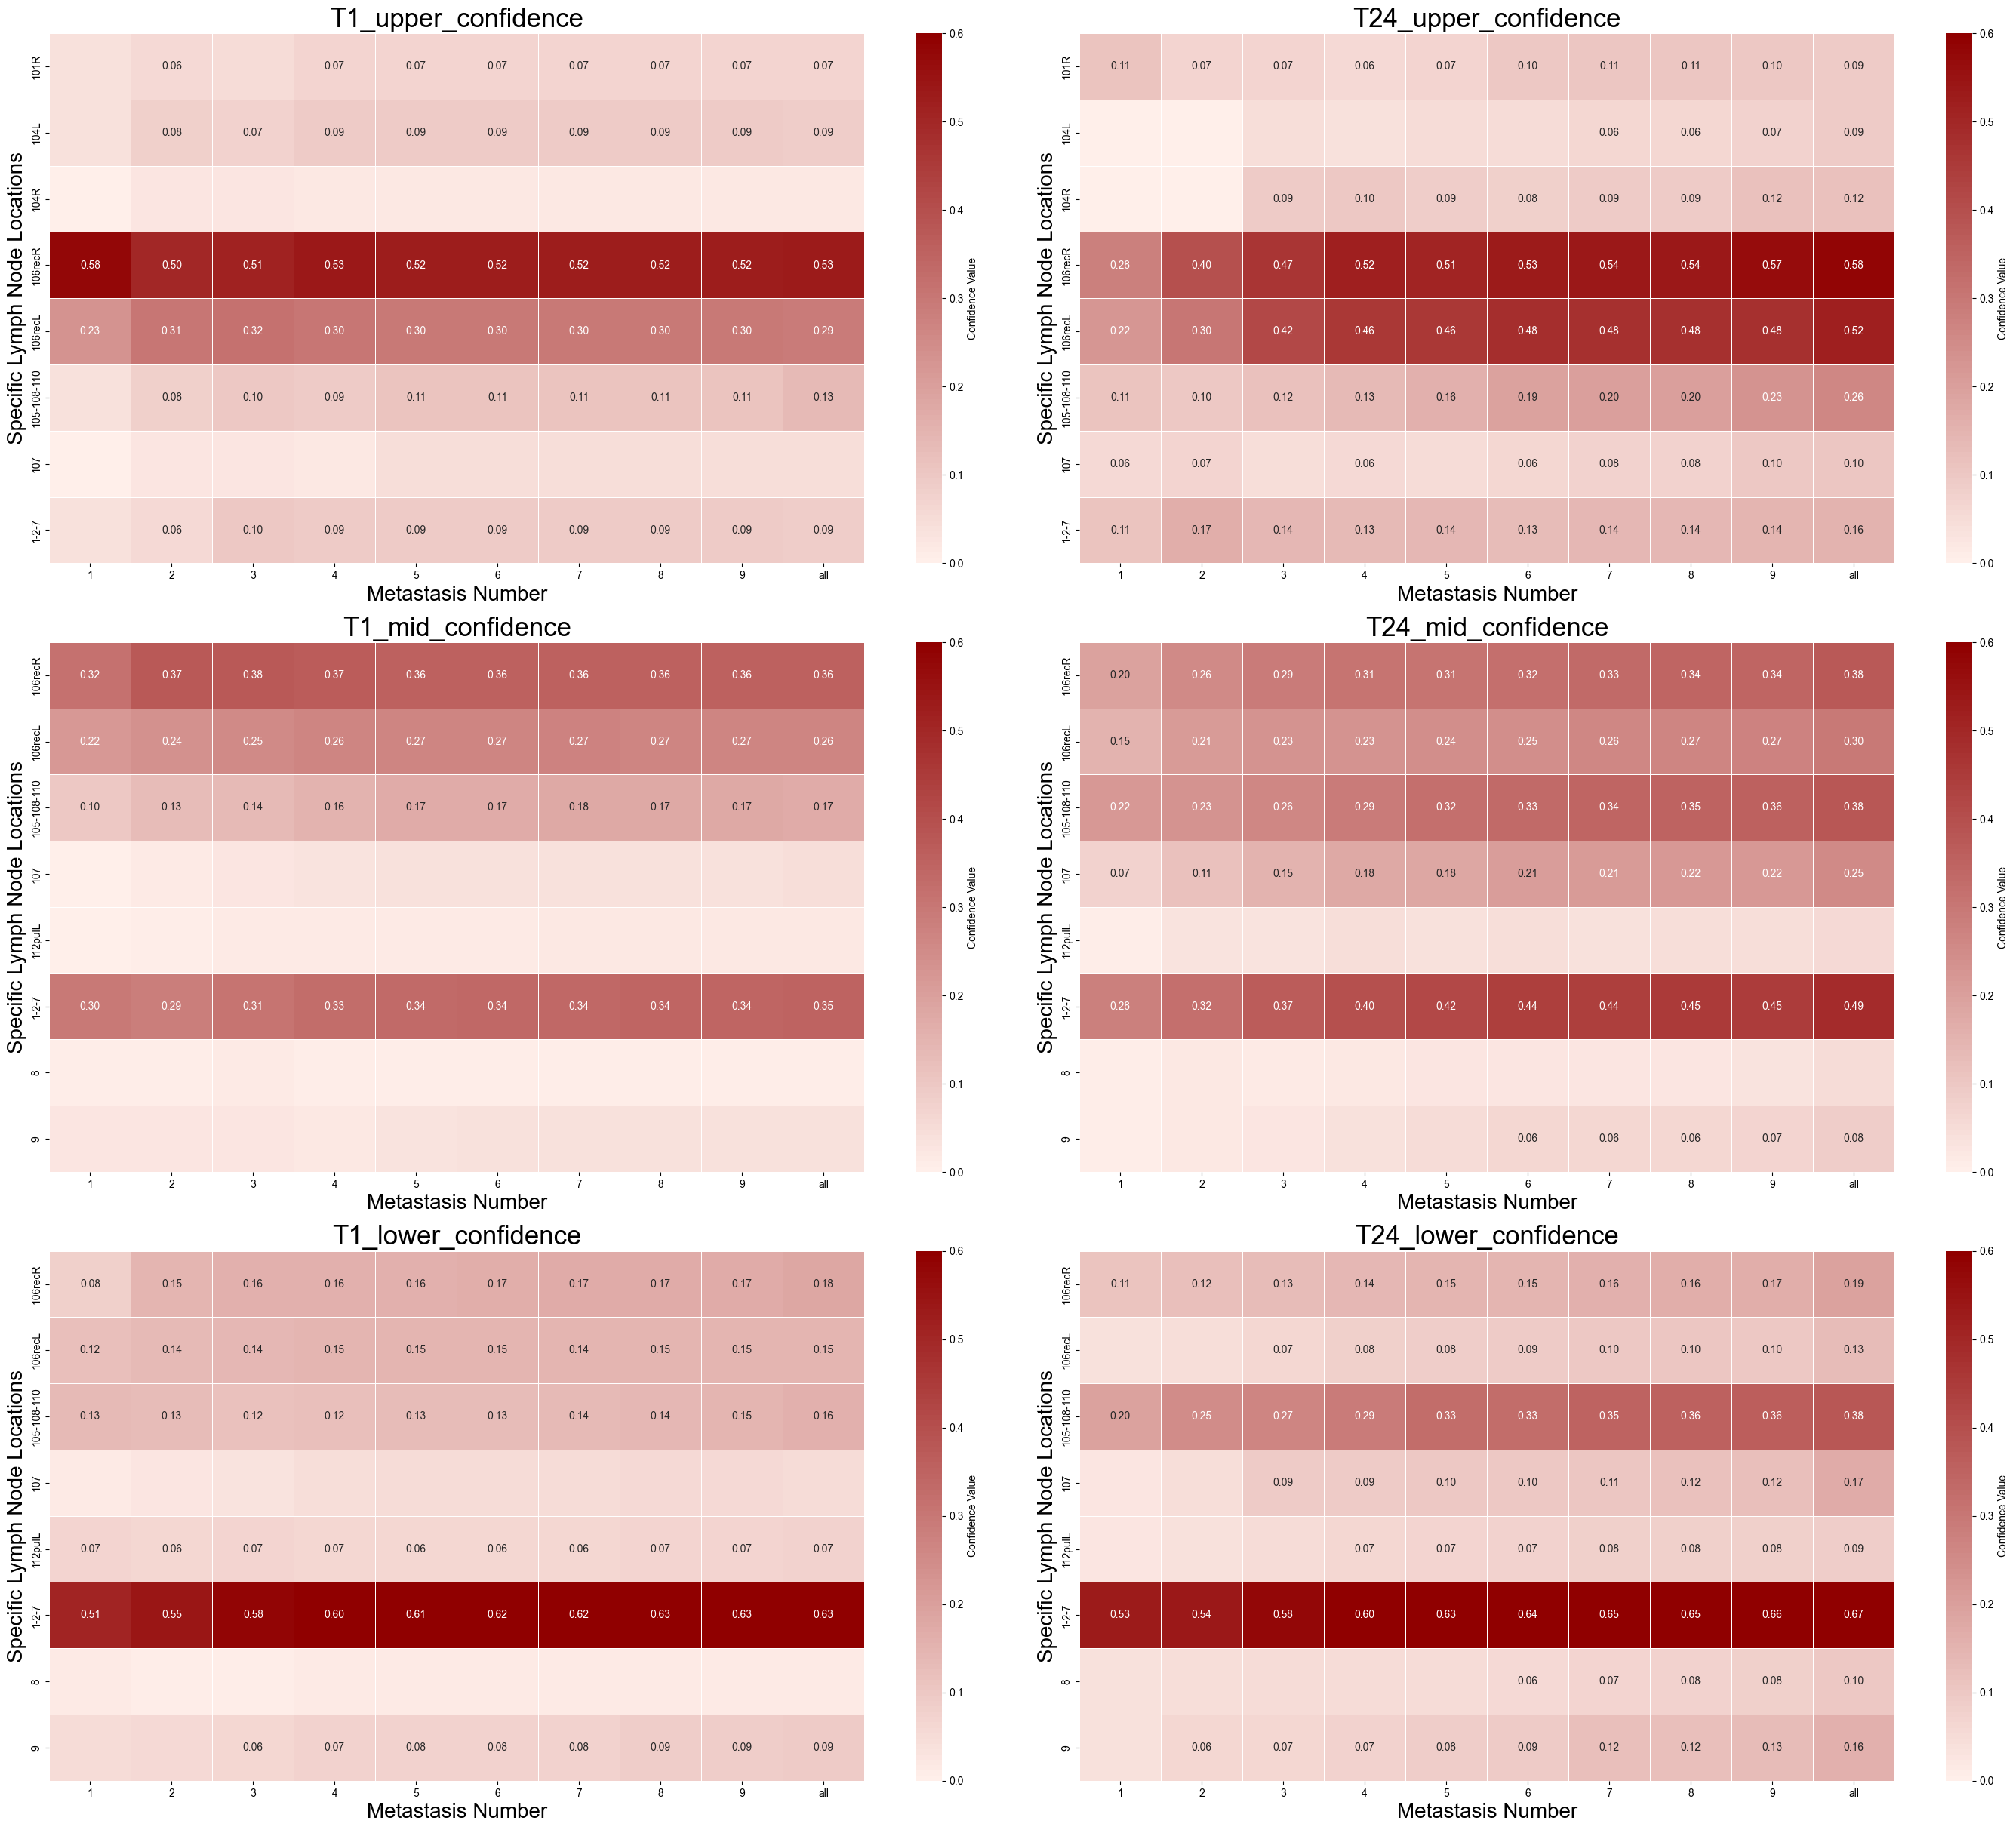

In [72]:
plot_multiple_transformed_heatmaps(transformed_dfs, transformed_descriptors, 'lower_confidence')

#### 2D Heat map for Hub Nodes

In [73]:
def get_frequency_TN(df, count, category):        
    # Defining the columns related to positive lymph node counts (excluding sum of regions)
    pos_columns = [col for col in df.columns if col.startswith('pos_')]
    
    # Excluding the specified columns from the lymph node stations
    excluded_columns = ["pos_neckLN", "pos_mediaLN", "pos_abdoLN", 
                        "pos_neckLN_new", "pos_mediaLN_new", "pos_abdoLN_new", 
                        "pos_ON", "pos_OM", "pos_OA"]
    specific_pos_columns = [col for col in pos_columns if col not in excluded_columns]
    
    # Filtering the patients based on counts and N_category
    if count == None:
        metastasis_df = df[df['N_category'] == category]
    if category == None:
        metastasis_df = df[df['total_pos_LN'] <= count]
        
    # Creating a list to store the edges of the network for up to 2 metastasis
    edges = []

    # Iterating through the filtered patients and creating edges from primary site to lymph node stations
    for index, row in metastasis_df.iterrows():        
        # Extracting the node stations with positive counts and ensuring the comparison is made with numeric values
        nodes = [col[4:] for col in specific_pos_columns if pd.to_numeric(row[col], errors='coerce') > 0]

        # Creating edges by connecting all the nodes within a patient
        patient_edges = [(nodes[i], nodes[j]) for i in range(len(nodes)) for j in range(i+1, len(nodes))]
        edges.extend(patient_edges)

    # Converting the edges to a DataFrame
    edges_df = pd.DataFrame(edges, columns=['Node_1', 'Node_2'])

    # Counting the frequency of each edge, then sort values
    edges_frequency = edges_df.groupby(['Node_1', 'Node_2']).size().reset_index(name='Frequency').sort_values(by='Frequency', ascending=False)

    return edges_frequency

# Function to identify hub nodes based on both unweighted degree and normalized strength
def identify_node_degrees(edge_frequency):
    # Initialize an empty graph
    G = nx.Graph()
    
    # Populate the graph based on edges and their frequencies
    for index, row in edge_frequency.iterrows():
        G.add_edge(row['Node_1'], row['Node_2'], weight=row['Frequency'])
    
    # Calculate the unweighted degree of each node
    node_degrees = dict(G.degree())
    
    # Calculate the total frequency (sum of all edge weights)
    total_frequency = sum(weight for _, _, weight in G.edges(data='weight'))
    
    # Calculate the normalized strength of each node
    node_normalized_strengths = {node: round(sum(weight / total_frequency for _, _, weight in G.edges(node, data='weight')), 3) for node in G.nodes()}
 
    # Create a DataFrame to store the nodes, their degrees, and normalized strengths
    hub_nodes_df = pd.DataFrame({
        'Node': list(node_degrees.keys()),
        'Unweighted Degree': list(node_degrees.values()),
        'Weighted Degree': [node_normalized_strengths.get(node, 0) for node in node_degrees.keys()]
    })
    
    # Sort the DataFrame based on both Weighted Degree
    hub_nodes_df.sort_values(by=['Weighted Degree'], ascending=[False], inplace=True)
    
    return hub_nodes_df

def find_union_hub_nodes(edge_frequency_A, edge_frequency_B, edge_frequency_C, edge_frequency_D, edge_frequency_E, edge_frequency_F, cutoff):
    # Predefined order of the lymphnodes
    predefined_order = ['101R', '101L', '102R', '102L', '104R', '104L', '106preR', '106preL', '106recR', 
                        '106recL', '107', '105-108-110', '112pulR', '112pulL', '1-2-7', '8', '9']
    
    # Identify the hub nodes for all edge frequencies
    hub_nodes_A = identify_node_degrees(edge_frequency_A)
    hub_nodes_B = identify_node_degrees(edge_frequency_B)
    hub_nodes_C = identify_node_degrees(edge_frequency_C)
    hub_nodes_D = identify_node_degrees(edge_frequency_D)
    hub_nodes_E = identify_node_degrees(edge_frequency_E)
    hub_nodes_F = identify_node_degrees(edge_frequency_F)

    # Filter the hub nodes based on the Weighted Degree value
    selected_hub_nodes_A = set(hub_nodes_A[hub_nodes_A['Weighted Degree'] >= cutoff]['Node'].tolist())
    selected_hub_nodes_B = set(hub_nodes_B[hub_nodes_B['Weighted Degree'] >= cutoff]['Node'].tolist())
    selected_hub_nodes_C = set(hub_nodes_C[hub_nodes_C['Weighted Degree'] >= cutoff]['Node'].tolist())
    selected_hub_nodes_D = set(hub_nodes_D[hub_nodes_D['Weighted Degree'] >= cutoff]['Node'].tolist())
    selected_hub_nodes_E = set(hub_nodes_E[hub_nodes_E['Weighted Degree'] >= cutoff]['Node'].tolist())
    selected_hub_nodes_F = set(hub_nodes_F[hub_nodes_F['Weighted Degree'] >= cutoff]['Node'].tolist())

    # Find the union of the hub nodes
    union_hub_nodes = selected_hub_nodes_A.union(selected_hub_nodes_B, selected_hub_nodes_C, selected_hub_nodes_D, selected_hub_nodes_E, selected_hub_nodes_F)

    # Sort the union_hub_nodes based on the predefined order
    sorted_union_hub_nodes = sorted(union_hub_nodes, key=lambda x: predefined_order.index(x) if x in predefined_order else float('inf'))

    return sorted_union_hub_nodes

In [74]:
def transform_for_heatmap_TN(descriptor1, descriptor2, num, metric):    
    metricVal = metric
    nums = ['2', '6', 'all']

    # Get six edge_frequency_df based on the three nums and the two descriptors
    edge_frequency_dfs = []
    for n in nums:
        for descriptor in [descriptor1, descriptor2]:
            ef_name = f"EF_TN_{n}_{descriptor}"
            edge_frequency_df = globals()[ef_name]
            edge_frequency_dfs.append(edge_frequency_df)
    
    # Assuming find_union_hub_nodes has been updated to accept 6 edge frequencies
    top_hub_nodes = find_union_hub_nodes(*edge_frequency_dfs, 0.2)
    print(top_hub_nodes)
    
    # Construct the DataFrame name for association rules
    df_name1 = f"associationRule_TN_{num}_{descriptor1}"
    df_name2 = f"associationRule_TN_{num}_{descriptor2}"
    
    df1 = globals()[df_name1]
    df2 = globals()[df_name2]

    rows_to_add1 = []
    rows_to_add2 = []
    
    # Filter rows based on specific hub nodes
    if metric =="zhangs_metric":
        for hub in top_hub_nodes:
            filtered_df1 = df1[df1['antecedents'] == hub]
            for idx, row in filtered_df1.iterrows():
                rows_to_add1.append({
                    'HubNodes': hub,
                    'LymphNode': row['consequents'],
                    metric: row[metricVal],
                    'interestingness': row['interestingness'] 
                })

            filtered_df2 = df2[df2['antecedents'] == hub]
            for idx, row in filtered_df2.iterrows():
                rows_to_add2.append({
                    'HubNodes': hub,
                    'LymphNode': row['consequents'],
                    metric: row[metricVal],
                    'interestingness': row['interestingness']   
                })      
        transformed_df1 = pd.DataFrame(columns=['HubNodes', 'LymphNode', metric, 'interestingness'])
        transformed_df2 = pd.DataFrame(columns=['HubNodes', 'LymphNode', metric, 'interestingness'])
        
    else: 
        for hub in top_hub_nodes:
            filtered_df1 = df1[df1['antecedents'] == hub]
            for idx, row in filtered_df1.iterrows():
                rows_to_add1.append({
                    'HubNodes': hub,
                    'LymphNode': row['consequents'],
                    metric: row[metricVal]
                })

            filtered_df2 = df2[df2['antecedents'] == hub]
            for idx, row in filtered_df2.iterrows():
                rows_to_add2.append({
                    'HubNodes': hub,
                    'LymphNode': row['consequents'],
                    metric: row[metricVal]
                })        

        # Initialize an empty DataFrame to store the transformed data
        transformed_df1 = pd.DataFrame(columns=['HubNodes', 'LymphNode', metric])
        transformed_df2 = pd.DataFrame(columns=['HubNodes', 'LymphNode', metric])

    # Use concat to add all the rows at once
    transformed_df1 = pd.concat([transformed_df1, pd.DataFrame(rows_to_add1)], ignore_index=True)
    transformed_df2 = pd.concat([transformed_df2, pd.DataFrame(rows_to_add2)], ignore_index=True)

    return transformed_df1, transformed_df2

def transform_for_heatmap_opposite_TN(descriptor1, descriptor2, num, metric):    
    if metric == 'Support':
        metricVal = 'support'
    elif metric == 'Confidence': 
        metricVal = 'confidence'
    else:
        raise ValueError("Unsupported metric value!")
    
    # Identify the top 5 hub nodes from edge frequencies
    ef_name1 = f"EF_TN_{num}_{descriptor1}"
    ef_name2 = f"EF_TN_{num}_{descriptor2}"
        
    # Get edge frequency dataframes
    edge_frequency_df1 = globals()[ef_name1]
    edge_frequency_df2 = globals()[ef_name2]
    
    # Find union hub nodes (top _ number)
    top_hub_nodes = find_union_hub_nodes(edge_frequency_df1, edge_frequency_df2, 0.2)
    print(top_hub_nodes)
    
    # Construct the DataFrame name for association rules
    df_name1 = f"associationRule_TN_{num}_{descriptor1}"
    df_name2 = f"associationRule_TN_{num}_{descriptor2}"
    
    df1 = globals()[df_name1]
    df2 = globals()[df_name2]

    rows_to_add1 = []
    rows_to_add2 = []
    
    # Filter rows based on specific hub nodes
    for hub in top_hub_nodes:
        filtered_df1 = df1[df1['consequents'] == hub]
        for idx, row in filtered_df1.iterrows():
            rows_to_add1.append({
                'LymphNode': row['antecedents'],
                'HubNodes': hub,
                metric: row[metricVal]
            })
            
        filtered_df2 = df2[df2['consequents'] == hub]
        for idx, row in filtered_df2.iterrows():
            rows_to_add2.append({
                'LymphNode': row['antecedents'],
                'HubNodes': hub,
                metric: row[metricVal]
            })        
    
    # Initialize an empty DataFrame to store the transformed data
    transformed_df1 = pd.DataFrame(columns=['LymphNode', 'HubNodes', metric])
    transformed_df2 = pd.DataFrame(columns=['LymphNode', 'HubNodes', metric])

    # Use concat to add all the rows at once
    transformed_df1 = pd.concat([transformed_df1, pd.DataFrame(rows_to_add1)], ignore_index=True)
    transformed_df2 = pd.concat([transformed_df2, pd.DataFrame(rows_to_add2)], ignore_index=True)
                
    return transformed_df1, transformed_df2

In [75]:
def plot_transformed_heatmap_TN(df, name):
    #Predefined order of the lymphnodes
    predefined_order = ['101R', '101L', '102R', '102L', '104R', '104L', '106preR', '106preL', '106recR', 
                        '106recL', '107', '105-108-110', '112pulR', '112pulL', '1-2-7', '8', '9']
    
    # Custom color map
    color_list = ['#ffefea', '#900000']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Create an empty DataFrame with all possible combinations
    unique_hub_nodes = df['HubNodes'].unique()
    unique_lymph_nodes = df['LymphNode'].unique()
    sorted_lymph_nodes = sorted(unique_lymph_nodes, key=lambda x: predefined_order.index(x) if x in predefined_order else float('inf'))

    heatmap_data = pd.DataFrame(index=unique_hub_nodes, columns=sorted_lymph_nodes)
    
    # Update it with actual data
    for idx, row in df.iterrows():
        heatmap_data.at[row['HubNodes'], row['LymphNode']] = row['Support']
    
    # Replace NaN with 0 for heatmap plotting
    heatmap_data.fillna(0, inplace=True)
    
    # Convert data to float
    heatmap_data = heatmap_data.astype(float)
    
    # Create a figure to hold the plot
    plt.figure(figsize=(15, 8))
    
    # Create the heatmap with fixed scale for colormap between 0 and 0.8
    sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Support Value'}, vmin=0, vmax=0.16)
    plt.title(f'Lymph Node Metastasis Heatmap for {name}')
    plt.xlabel('Specific Lymph Node Stations')
    plt.ylabel('Hub Nodes')
    plt.tight_layout()
    
    plt.show()
    
def plot_multiple_transformed_heatmaps_TN(dfs, names, title, metric):
    """
    Generate multiple heatmaps using a list of transformed DataFrames.
    
    Parameters:
    dfs (list): List of transformed DataFrames suitable for heatmap plotting
    names (list): List of names for the heatmap titles
    """
    # Set the font to Arial
    plt.rcParams['font.family'] = 'Arial'
    
    #Predefined order of the lymphnodes
    predefined_order = ['101R', '101L', '102R', '102L', '104R', '104L', '106preR', '106preL', '106recR', 
                        '106recL', '107', '105-108-110', '112pulR', '112pulL', '1-2-7', '8', '9']
    
    # Create a figure to hold the subplots
    plt.figure(figsize=(28, 8 * len(dfs)))
    
    # Set vmin and vmax values based on the metric
    if metric == "support":
        vmin_val, vmax_val = 0, 0.2
        color_list = ['#ffefea', '#900000']      
    elif metric == "net confidence" or metric == "attributable confidence" or metric == "zhangs_metric" or metric == "certain factor":
        vmin_val, vmax_val = -1, 1
        color_list = ['#0EFF00', '#F0F0F0', '#0B0B45']  # Green, Gray, Blue
    elif metric == "conviction":
        vmin_val, vmax_val = 0, 2
        color_list = ['#0EFF00', '#F0F0F0', '#0B0B45']  # Green, Gray, Blue
    elif metric == "interestingness":
        vmin_val, vmax_val = 0, 0.2
        color_list = ['#ffefea', '#900000']      
    else:
        raise ValueError("Unsupported metric value!")
        
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)

    all_unique_lymph_nodes = set()
    
    for df in dfs:
        # Unique lymph nodes from the DataFrame
        unique_lymph_nodes = df['LymphNode'].unique()
        
        # Add unique lymph nodes from the current dataframe to the accumulating set
        all_unique_lymph_nodes.update(unique_lymph_nodes)
    
    for i, (df, name) in enumerate(zip(dfs, names)):
        plt.subplot(len(dfs), 2, i + 1)
        
        # Unique hub nodes and lymph nodes from the DataFrame
        unique_hub_nodes = df['HubNodes'].unique()
        
        # Sort unique_lymph_nodes based on hub_nodes_sorted and predefined_order
        nodes_sorted_first = [node for node in unique_hub_nodes if node in all_unique_lymph_nodes]
        remaining_nodes = [node for node in predefined_order if node not in nodes_sorted_first and node in all_unique_lymph_nodes]
        all_nodes_sorted = nodes_sorted_first + remaining_nodes
        
        # Create an empty DataFrame with all possible combinations
        heatmap_data = pd.DataFrame(index=unique_hub_nodes, columns=all_nodes_sorted)

        # Update it with actual data
        for idx, row in df.iterrows():
            value = row[metric]
            # Check for Zhang's metric and corresponding interestingness value
            if metric == "zhangs_metric" and df.at[idx, "interestingness"] < 0.00:
                heatmap_data.at[row['HubNodes'], row['LymphNode']] = 0  
            else:
                heatmap_data.at[row['HubNodes'], row['LymphNode']] = value
                
        # Convert heatmap_data to float type
        heatmap_data = heatmap_data.astype(float)

        # Replace NaN with 0 for heatmap plotting
        heatmap_data.fillna(0, inplace=True)
        
        if metric == 'conviction':
            heatmap_data.replace(0, np.nan, inplace=True)  # Replace 0.00 with NaN for conviction
        
        # Plot heatmap
        if heatmap_data.shape[0] == 1 or heatmap_data.shape[1] == 1:
            ax = sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': f'{metric.capitalize()} Value'}, vmin=vmin_val, vmax=vmax_val, cbar=False)
        else:
            ax = sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': f'{metric.capitalize()} Value'}, vmin=vmin_val, vmax=vmax_val)

        for text in ax.texts:
            text_str = text.get_text()
            if metric == 'support':
                if text_str and float(text_str) < 0.02:
                    text.set_text('')
            if metric == 'zhangs_metric':
                if text_str and -0.5 <= float(text_str) <= 0.5:
                    text.set_text('')
            if metric == 'net confidence' or metric == "attributable confidence" or metric == "certain factor":
                if text_str and -0.05 <= float(text_str) <= 0.05:
                    text.set_text('')                
            if metric == 'conviction':          
                if text_str and 0.99 <= float(text_str) <= 1.01:
                    text.set_text('')                
            if metric == 'interestingness':
                if text_str and float(text_str) < 0.02:
                    text.set_text('')   
        ax.axvline(x=len(unique_hub_nodes), color='black', linewidth=1.5)

        # Adjust colorbar label size
        cbar = ax.collections[0].colorbar
        cbar.ax.set_ylabel(f'{metric.capitalize()} Value', size=14)

        # # Add a border around the heatmap
        if metric == 'conviction':
            for _, spine in ax.spines.items():
                spine.set_visible(True)
        
        plt.title(f'{name}_{metric}', fontsize=25)
        plt.xlabel('Specific LN Stations', fontsize=20)
        plt.ylabel('Hub LN Stations', fontsize=20)
    
    plt.tight_layout()
    # Save the figure
    save_path = f"../Results/2D_Heatmap_TN_{title}.png"
    plt.savefig(save_path)
    
    save_path_svg = f"../Results/2D_Heatmap_TN_{title}.svg"
    plt.savefig(save_path_svg, format='svg')    
    
    plt.show()
    plt.show()

In [76]:
#Get edges frequencies based on Numbers
for descriptor in dataset_descriptors:
    for num in numbers:
        label = 'all' if num == 44 else str(num)
        # Create the global variable name
        var_name = f"EF_TN_{label}_{descriptor}"
        # Create the dataframe variable name
        df_name = f"{descriptor}_df"
        # Assign the result to the global variable
        globals()[var_name] = get_frequency_TN(globals()[df_name], num, None)
        
#Get edges frequency based on N categories
for descriptor in dataset_descriptors:
    for category in N_categories:
        label = f'N{category}'
        # Create the global variable name
        var_name = f"EF_TN_{label}_{descriptor}"
        # Create the dataframe variable name
        df_name = f"{descriptor}_df"
        # Assign the result to the global variable
        globals()[var_name] = get_frequency_TN(globals()[df_name], None, category)

In [77]:
transformed_TN_df_T1_all, transformed_TN_df_T24_all = transform_for_heatmap_TN('T1', 'T24', 'all', 'support')

['106recR', '106recL', '107', '105-108-110', '1-2-7']


In [78]:
#Support 
transformed_TN_df_T1_upper_all_Support, transformed_TN_df_T24_upper_all_Support = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'support')
transformed_TN_df_T1_mid_all_Support, transformed_TN_df_T24_mid_all_Support = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'support')
transformed_TN_df_T1_lower_all_Support, transformed_TN_df_T24_lower_all_Support = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'support')

#Net Confidence
transformed_TN_df_T1_upper_all_NC, transformed_TN_df_T24_upper_all_NC = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'net confidence')
transformed_TN_df_T1_mid_all_NC, transformed_TN_df_T24_mid_all_NC = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'net confidence')
transformed_TN_df_T1_lower_all_NC, transformed_TN_df_T24_lower_all_NC = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'net confidence')

#Attributable Confidence
transformed_TN_df_T1_upper_all_AC, transformed_TN_df_T24_upper_all_AC = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'attributable confidence')
transformed_TN_df_T1_mid_all_AC, transformed_TN_df_T24_mid_all_AC = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'attributable confidence')
transformed_TN_df_T1_lower_all_AC, transformed_TN_df_T24_lower_all_AC = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'attributable confidence')

#Zhangs Metric
transformed_TN_df_T1_upper_all_ZM, transformed_TN_df_T24_upper_all_ZM = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'zhangs_metric')
transformed_TN_df_T1_mid_all_ZM, transformed_TN_df_T24_mid_all_ZM = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'zhangs_metric')
transformed_TN_df_T1_lower_all_ZM, transformed_TN_df_T24_lower_all_ZM = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'zhangs_metric')

#Conviction
transformed_TN_df_T1_upper_all_Conviction, transformed_TN_df_T24_upper_all_Conviction = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'conviction')
transformed_TN_df_T1_mid_all_Conviction, transformed_TN_df_T24_mid_all_Conviction = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'conviction')
transformed_TN_df_T1_lower_all_Conviction, transformed_TN_df_T24_lower_all_Conviction = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'conviction')

#Certain Factor
transformed_TN_df_T1_upper_all_CF, transformed_TN_df_T24_upper_all_CF = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'certain factor')
transformed_TN_df_T1_mid_all_CF, transformed_TN_df_T24_mid_all_CF = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'certain factor')
transformed_TN_df_T1_lower_all_CF, transformed_TN_df_T24_lower_all_CF = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'certain factor')

#Interestingness
transformed_TN_df_T1_upper_all_Interestingness, transformed_TN_df_T24_upper_all_Interestingness = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'interestingness')
transformed_TN_df_T1_mid_all_Interestingness, transformed_TN_df_T24_mid_all_Interestingness = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'interestingness')
transformed_TN_df_T1_lower_all_Interestingness, transformed_TN_df_T24_lower_all_Interestingness = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'interestingness')

['104L', '106recR', '106recL', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7', '9']
['104L', '106recR', '106recL', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7', '9']
['104L', '106recR', '106recL', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7', '9']
['104L', '106recR', '106recL', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7', '9']
['104L', '106recR', '106recL', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7', '9']
['104L', '106recR', '106recL', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7

In [79]:
transformed_support_dfs = [transformed_TN_df_T1_upper_all_Support, transformed_TN_df_T24_upper_all_Support, transformed_TN_df_T1_mid_all_Support, transformed_TN_df_T24_mid_all_Support, transformed_TN_df_T1_lower_all_Support, transformed_TN_df_T24_lower_all_Support]
transformed_ZM_dfs = [transformed_TN_df_T1_upper_all_ZM, transformed_TN_df_T24_upper_all_ZM, transformed_TN_df_T1_mid_all_ZM, transformed_TN_df_T24_mid_all_ZM, transformed_TN_df_T1_lower_all_ZM, transformed_TN_df_T24_lower_all_ZM]
transformed_Interestingness_dfs = [transformed_TN_df_T1_upper_all_Interestingness, transformed_TN_df_T24_upper_all_Interestingness, transformed_TN_df_T1_mid_all_Interestingness, transformed_TN_df_T24_mid_all_Interestingness, transformed_TN_df_T1_lower_all_Interestingness, transformed_TN_df_T24_lower_all_Interestingness]

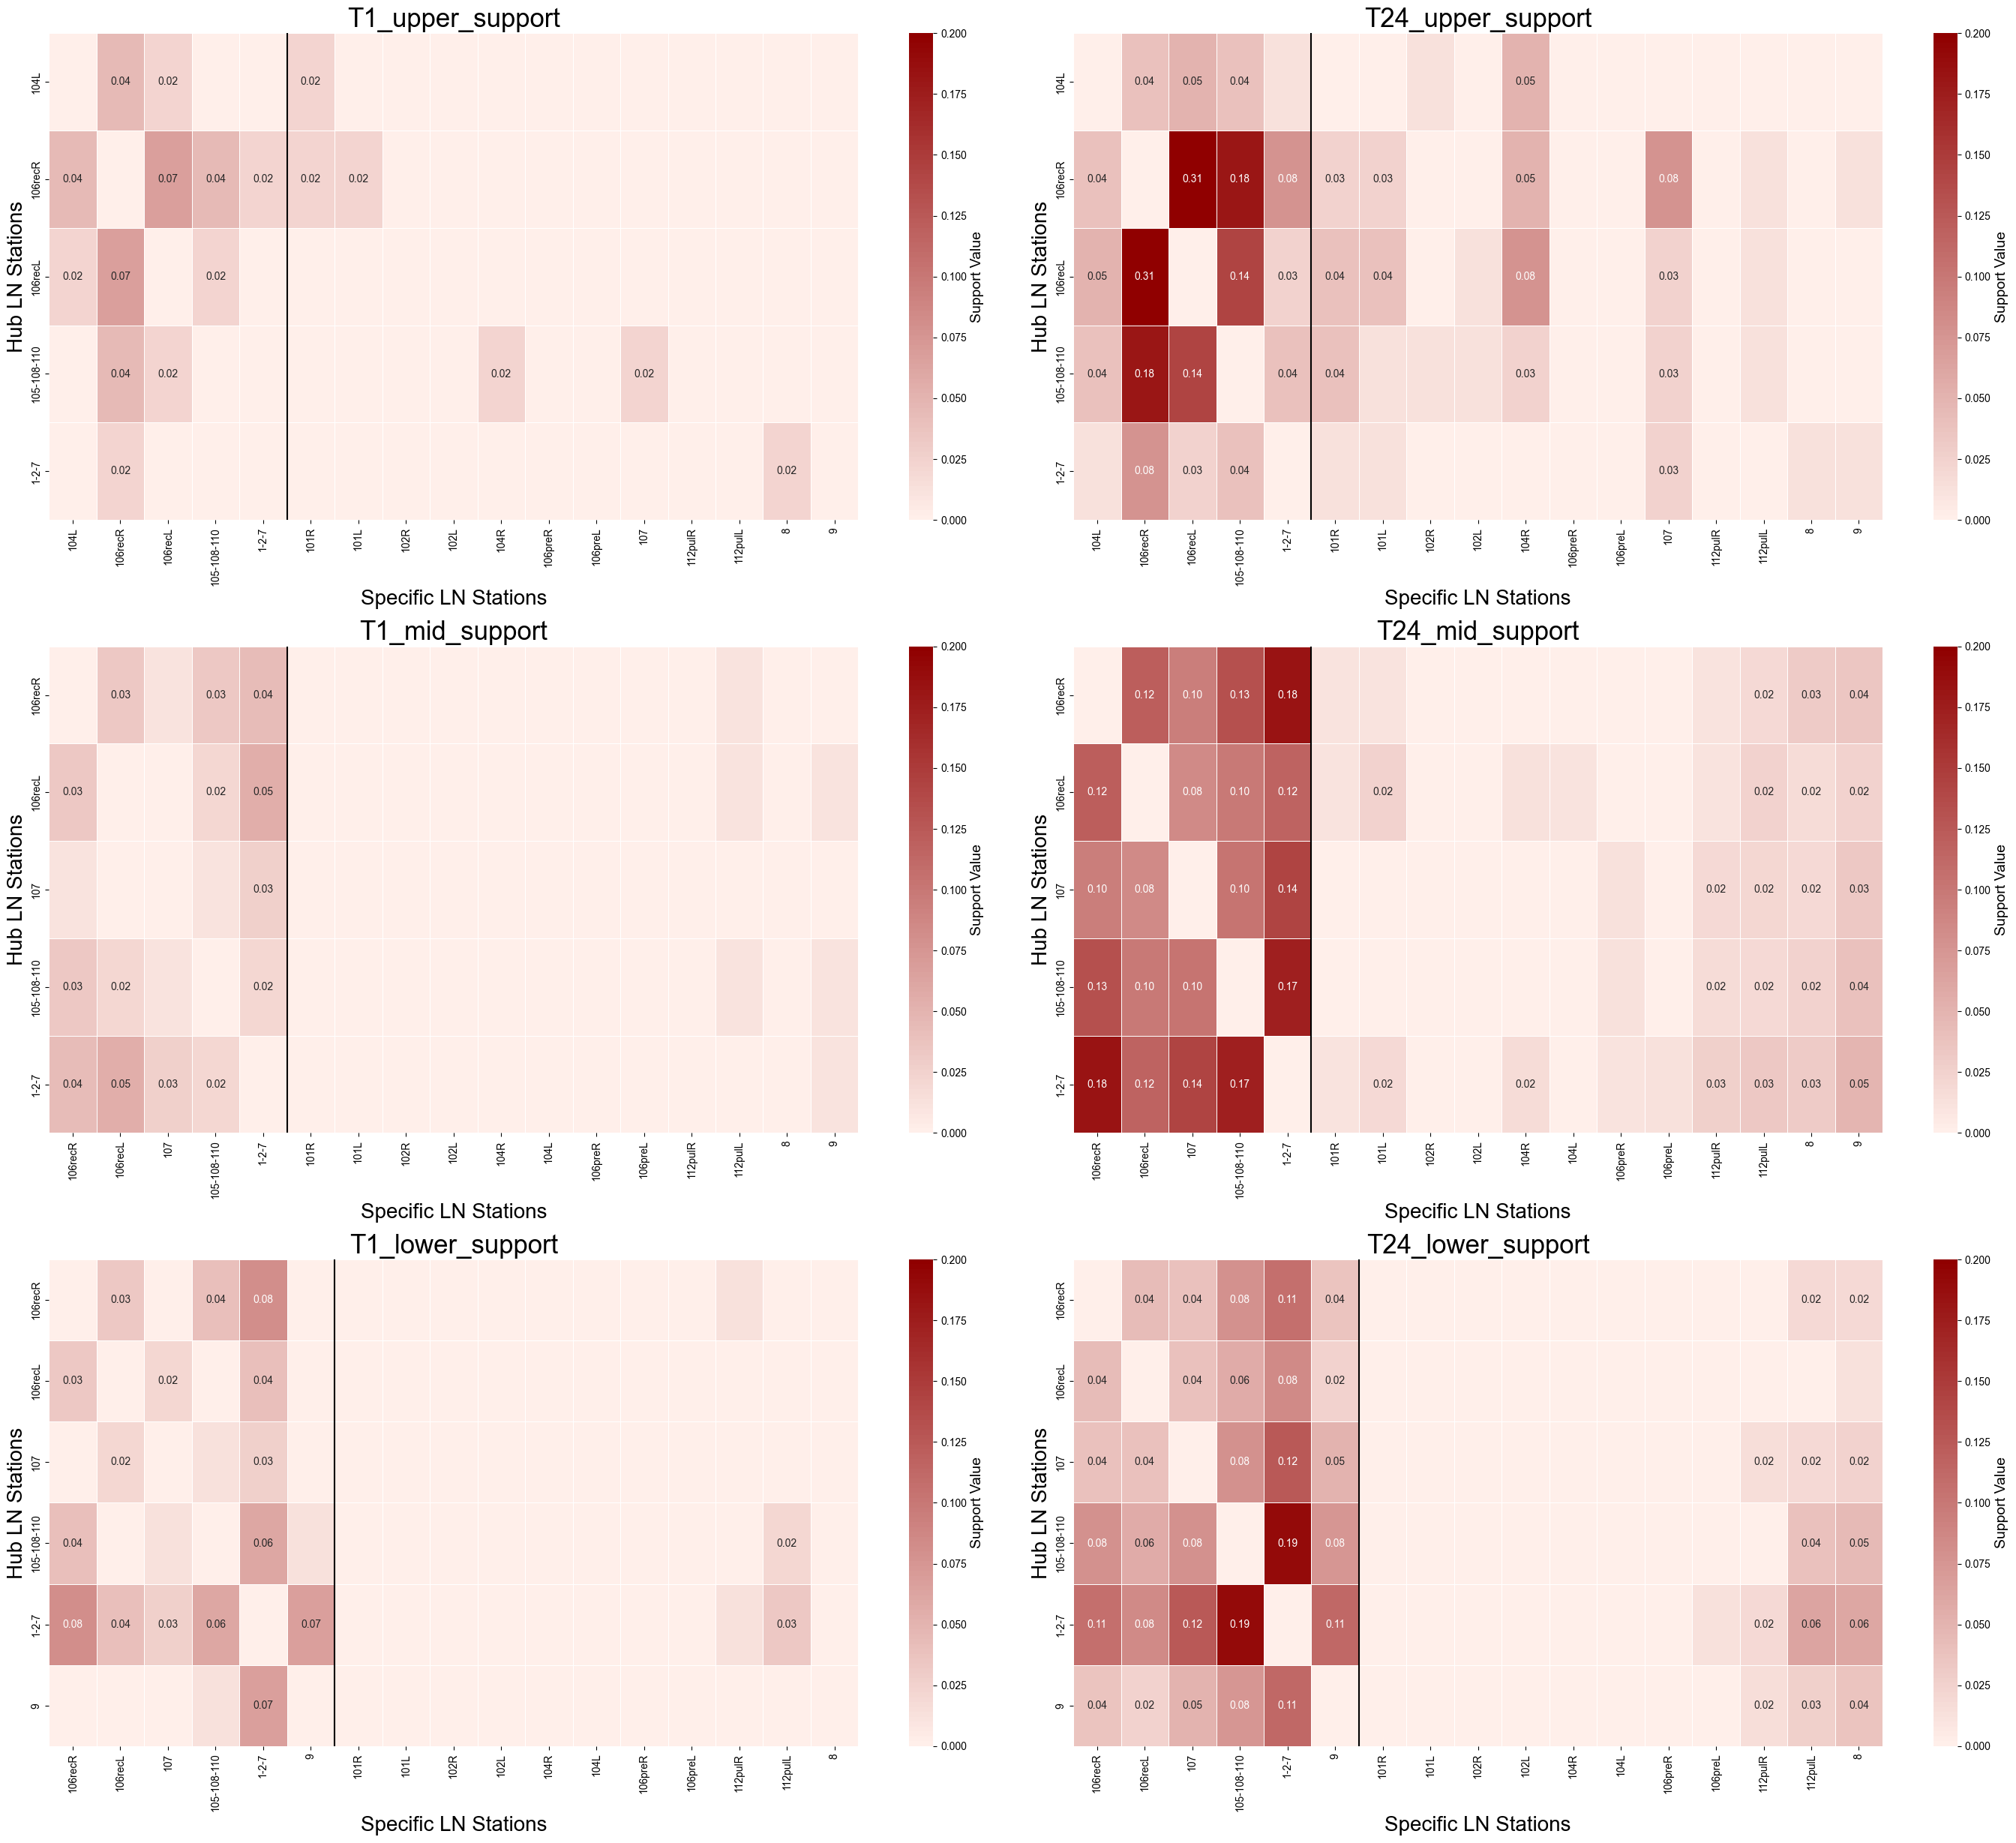

In [80]:
plot_multiple_transformed_heatmaps_TN(transformed_support_dfs,  transformed_descriptors, 'Support', 'support')

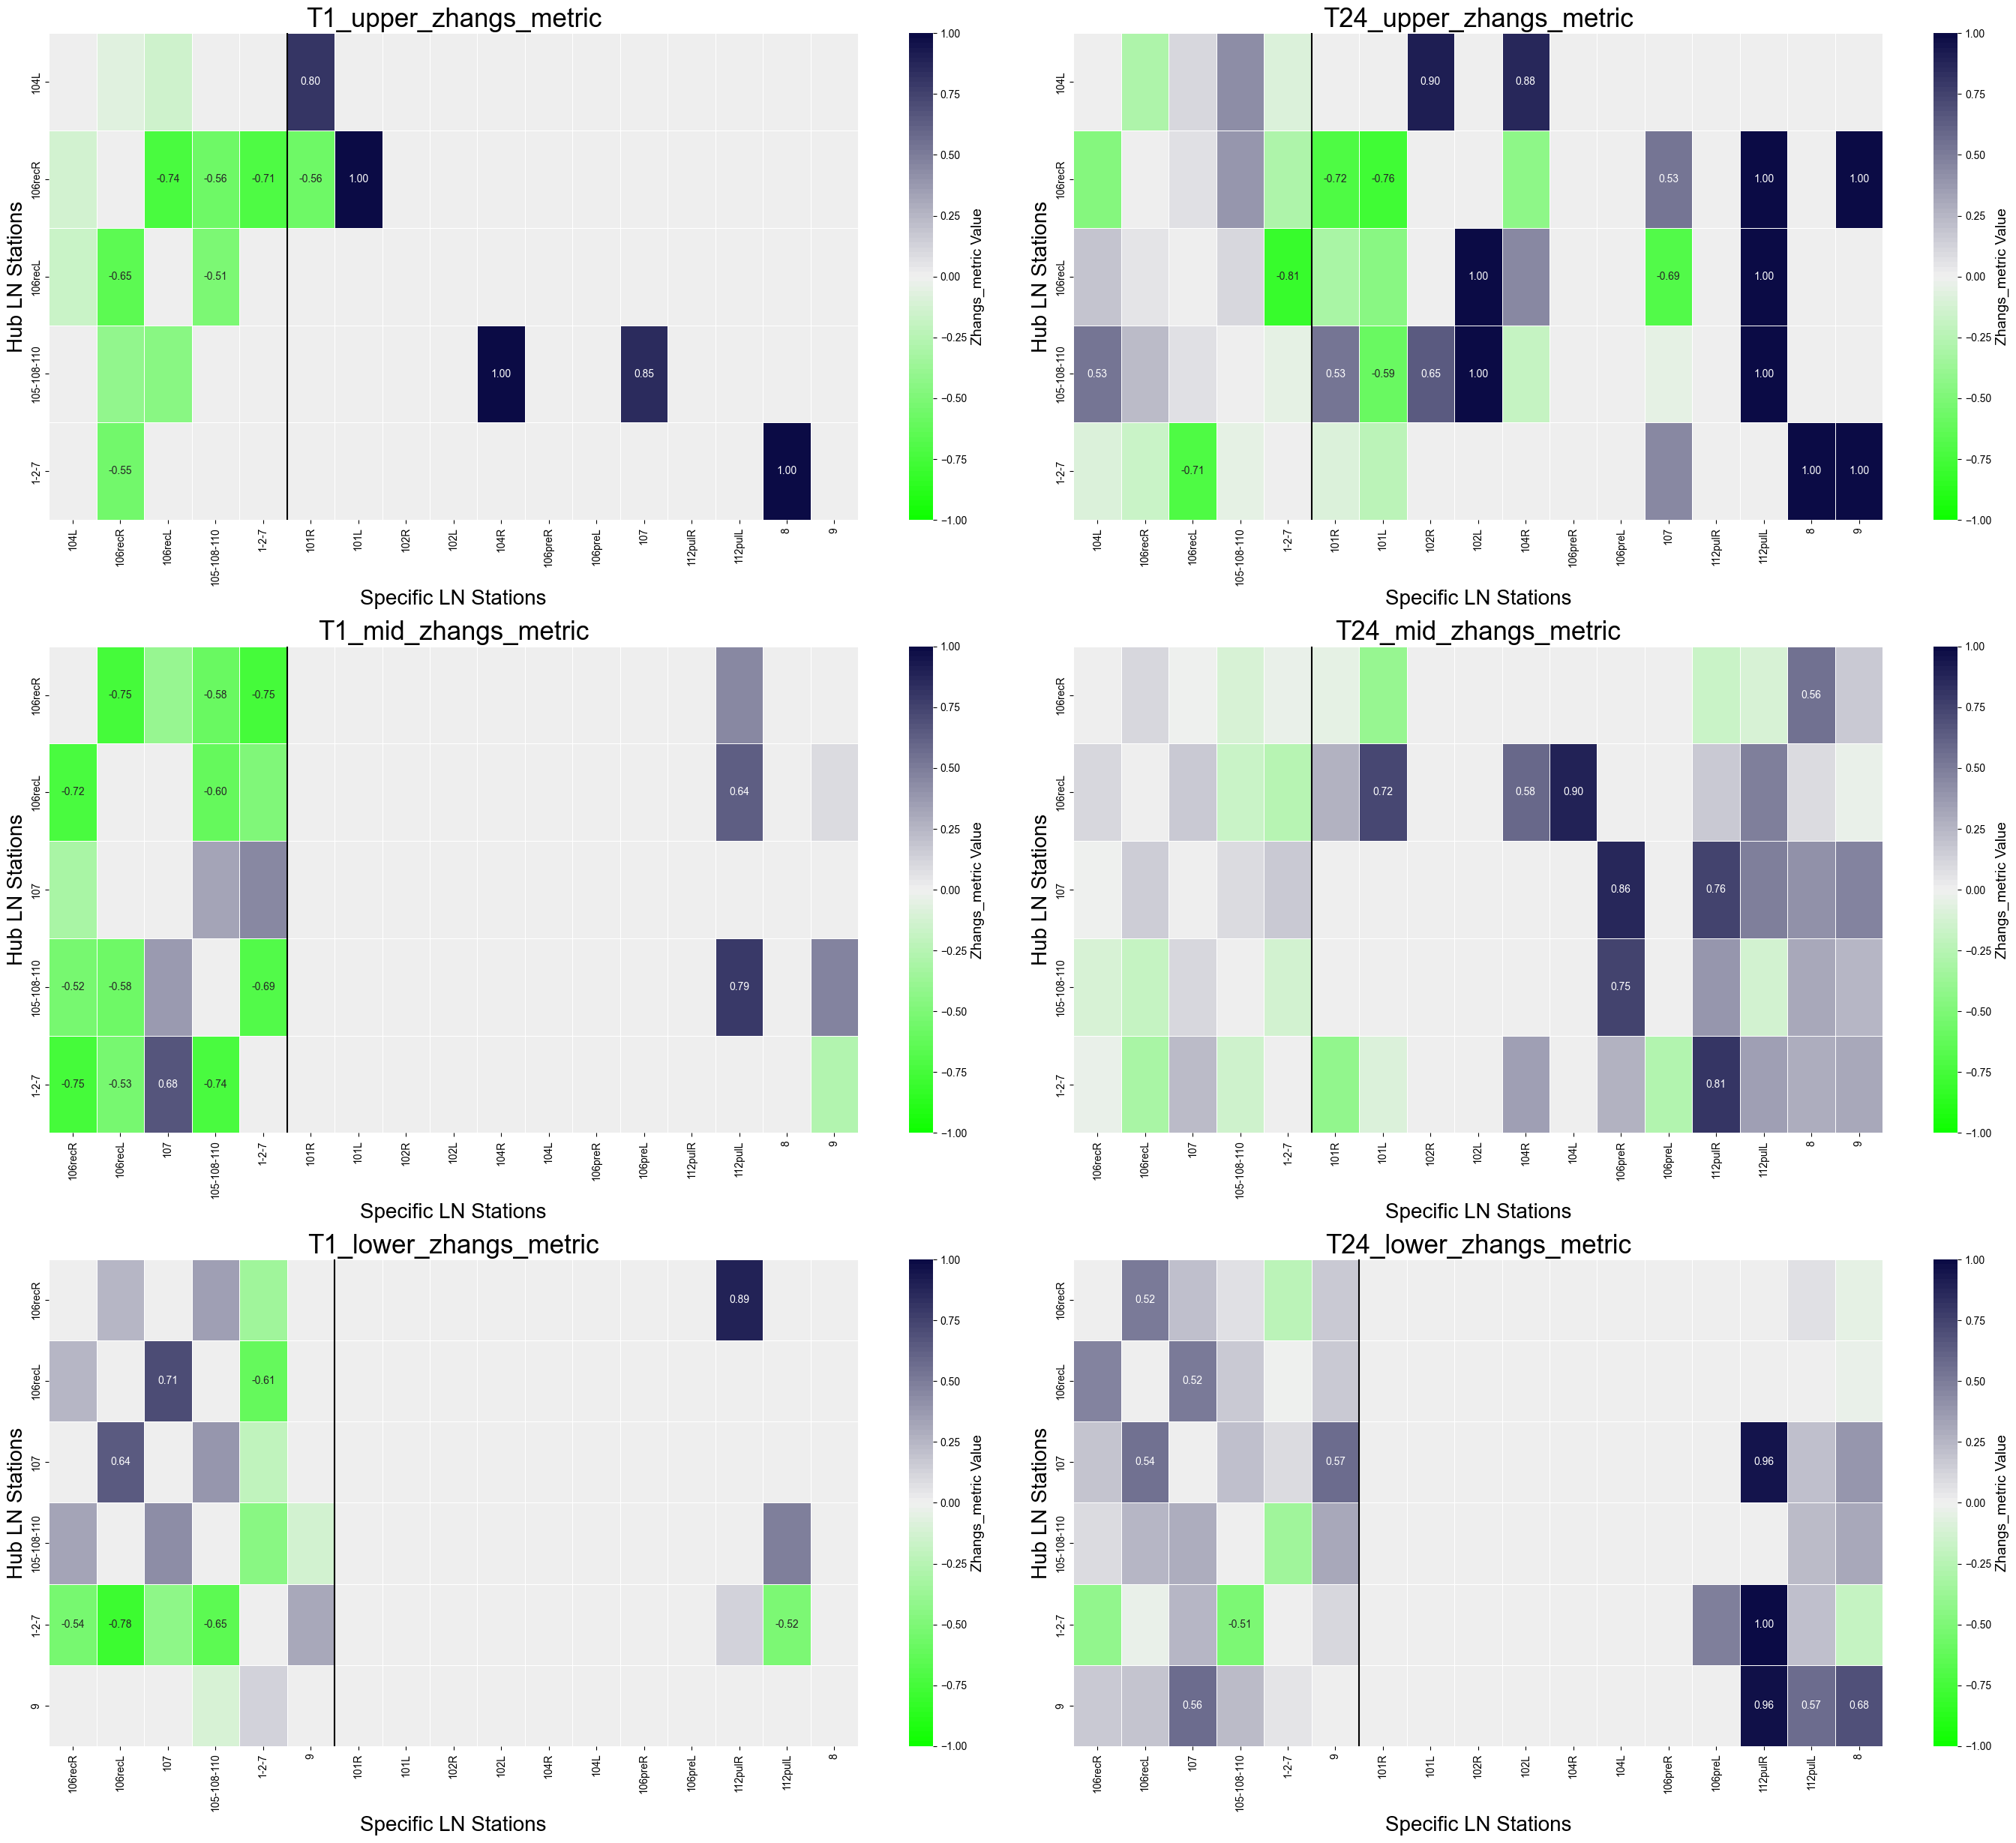

In [81]:
# Create the multiple heatmaps (Zhangs Metric) 
plot_multiple_transformed_heatmaps_TN(transformed_ZM_dfs, transformed_descriptors, 'Zhangs_Metric', 'zhangs_metric')

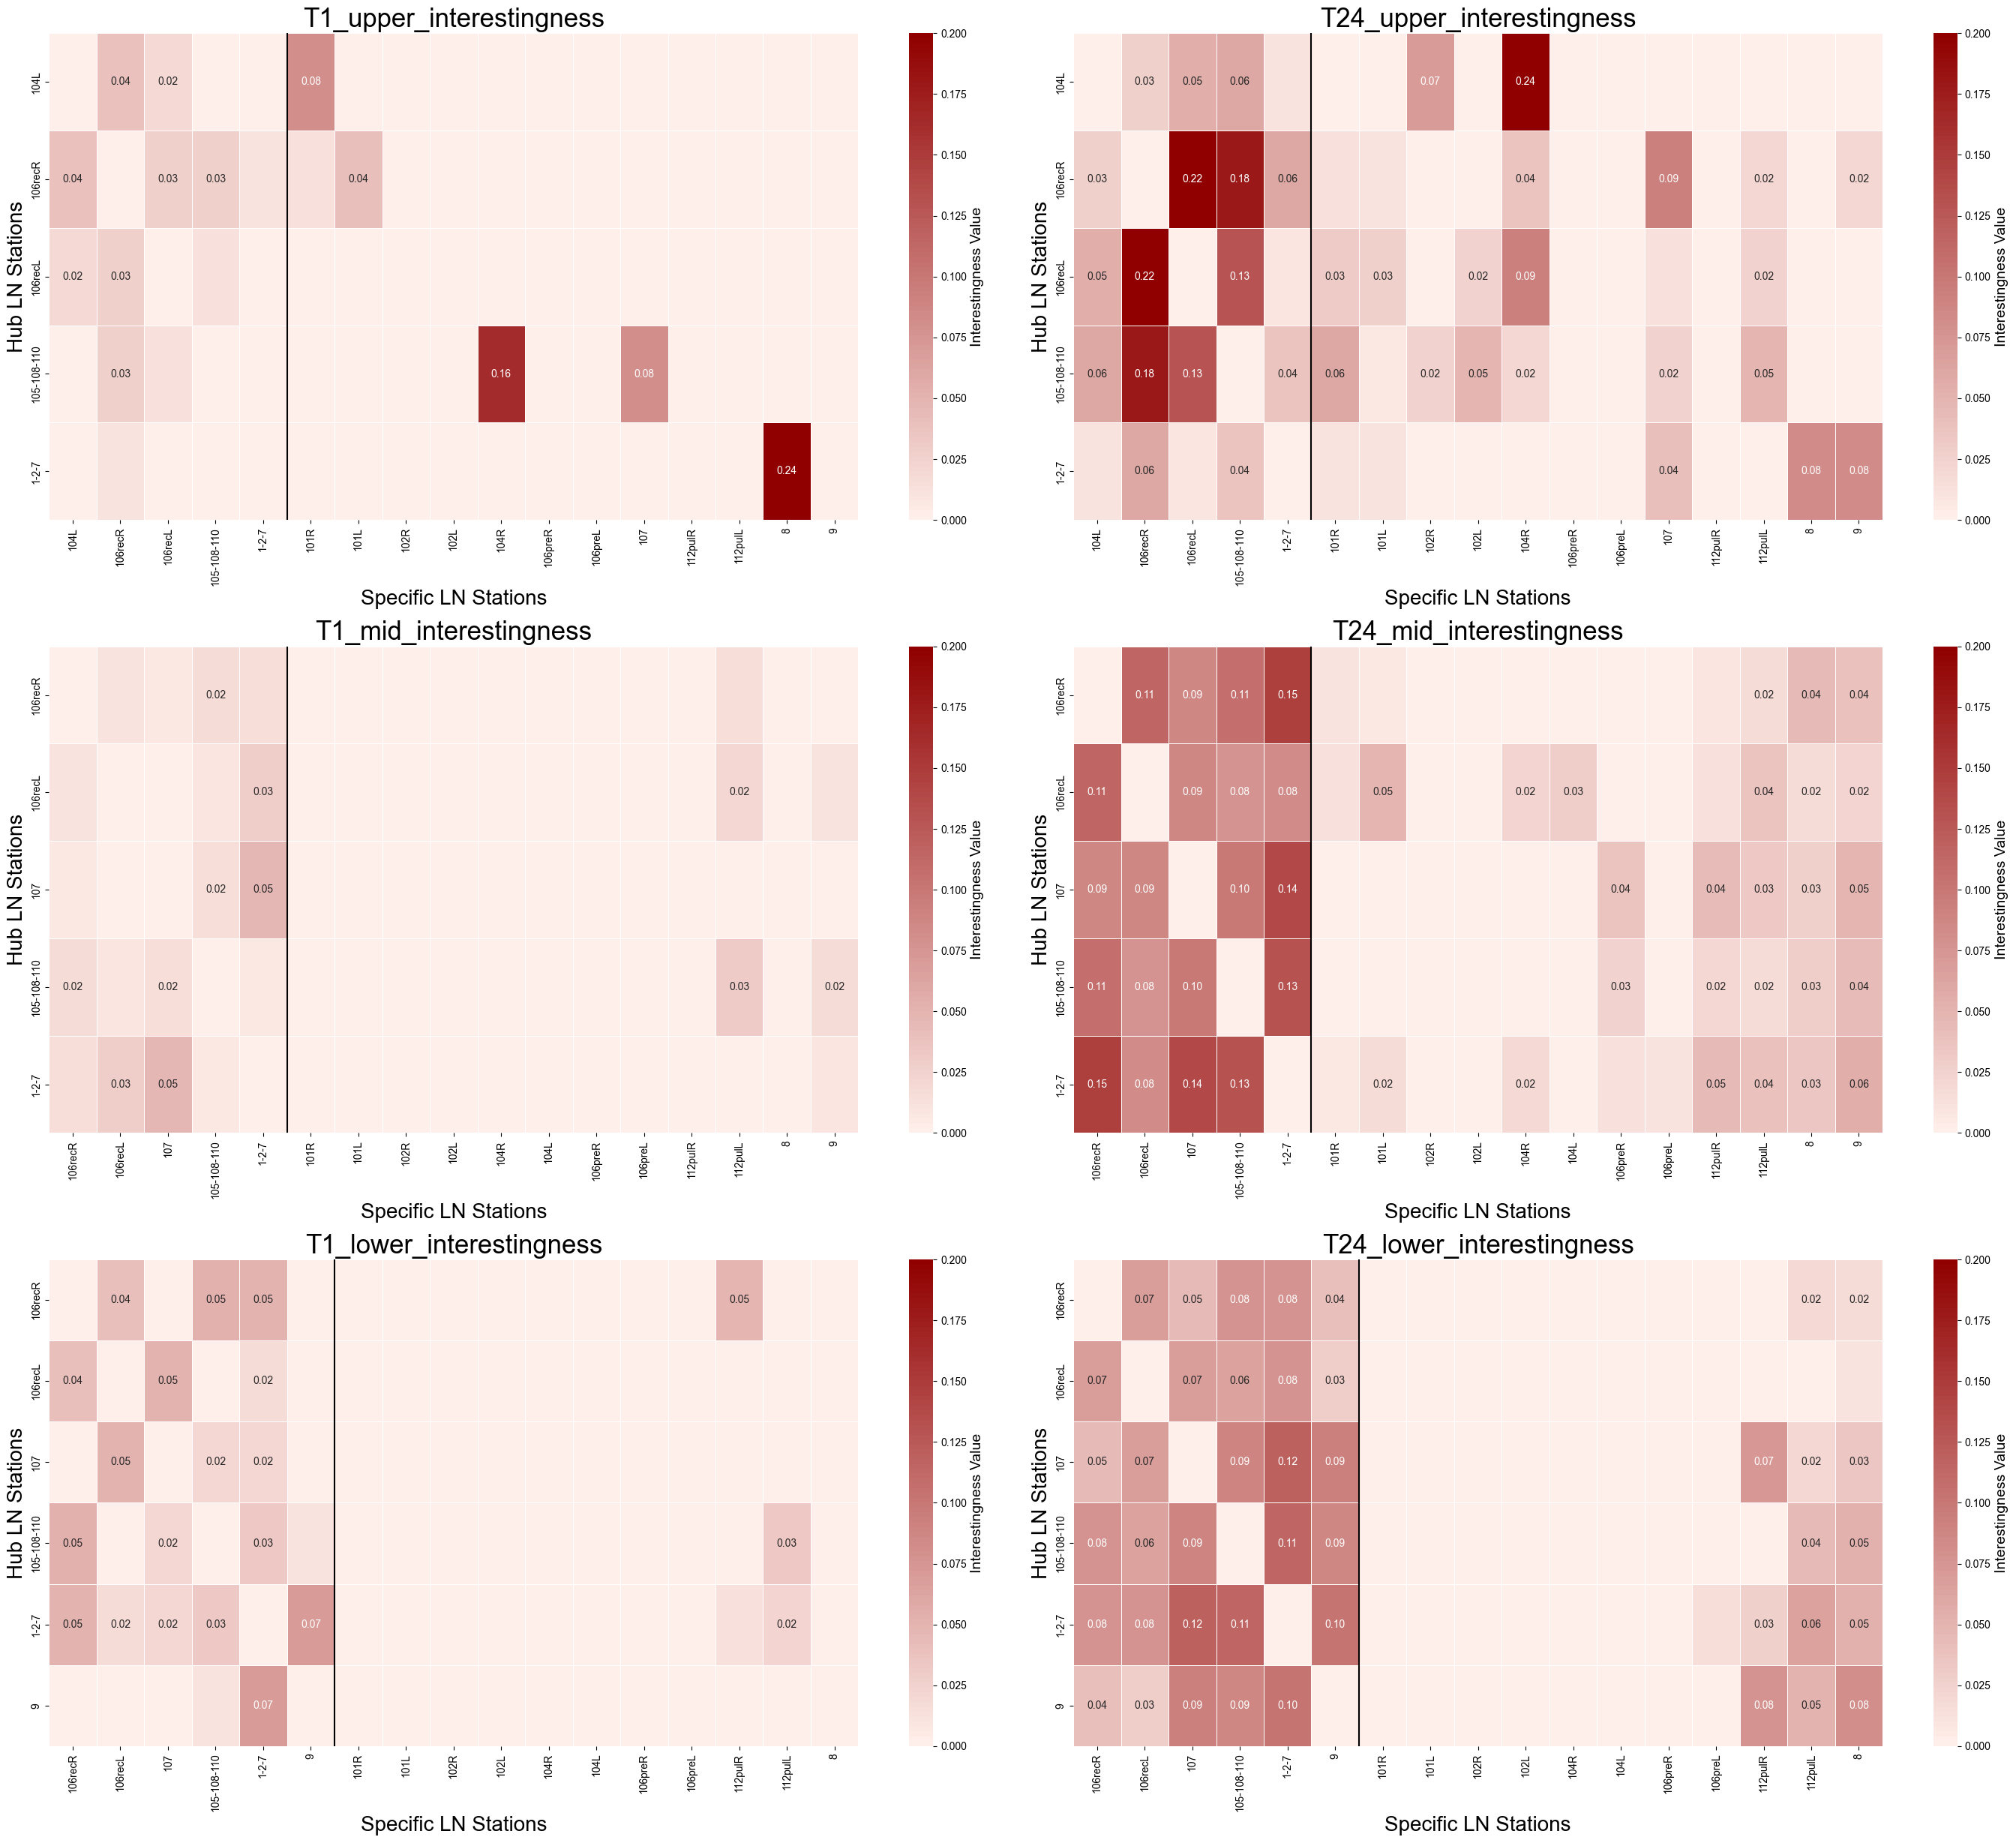

In [82]:
# Create the multiple heatmaps (interestingness) 
plot_multiple_transformed_heatmaps_TN(transformed_Interestingness_dfs, transformed_descriptors, 'Interestingness', 'interestingness')

#### Network of Zhang's metric and Support values 

In [113]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth
import networkx as nx

#Custom Positions of the Lymphnodes (Referring to diagram) 
#ON = other neck; OM=other medial; OA=other abdominal; REG=regional
Lymphnode_Positions = {
    'upper': (0, 3),
    'mid': (0, 0),
    'lower': (0, -3),
    "neckLN": (0, 3),
    "mediaLN": (0, 0),
    "abdoLN": (0, -3),
    '101R': (-0.2, 4),
    '101L': (0.2, 4),
    '102R': (-0.4, 4.3),
    '102L': (0.4, 4.3),
    '104R': (-0.6, 4),
    '104L': (0.6, 4),
    '106recR': (-0.3, 3),
    '106recL': (0.3, 3),
    '106preR': (-0.05, 2.5),
    '106preL': (0.5, 2.5),
    '107': (0.1, 1.5), 
    '105-108-110': (-0.4, 0.5), #*105
    '112pulR': (0, -0.3),
    '112pulL': (0.3, -0.3),
    '1-2-7': (0.4, -2.5),
    '8': (-0.4, -2.5),
    '9': (0, -3)
}

Label_Positions = {
    'upper': (0, 2.9),
    'mid': (0, -0.1),
    'lower': (0, -3.1),
    "neckLN": (0, 2.9),
    "mediaLN": (0, -0.1),
    "abdoLN": (0, -3.1),
    '101R': (-0.2, 3.9),
    '101L': (0.2, 3.9),
    '102R': (-0.4, 4.2),
    '102L': (0.4, 4.2),
    '104R': (-0.6, 3.9),
    '104L': (0.6, 3.9),
    '106recR': (-0.3, 2.9),
    '106recL': (0.3, 2.9),
    '106preR': (-0.05, 2.4),
    '106preL': (0.5, 2.4),
    '107': (0.1, 1.4), 
    '105-108-110': (-0.4, 0.4), #*105
    '112pulR': (0, -0.4),
    '112pulL': (0.3, -0.4),
    '1-2-7': (0.4, -2.6),
    '8': (-0.4, -2.6),
    '9': (0, -3.1)
}

In [84]:
def find_hub_nodes(edge_frequency_A, edge_frequency_B, edge_frequency_C, cutoff):
    # Predefined order of the lymphnodes
    predefined_order = ['101R', '101L', '102R', '102L', '104R', '104L', '106preR', '106preL', '106recR', 
                        '106recL', '107', '105-108-110', '112pulR', '112pulL', '1-2-7', '8', '9']
    
    # Identify the hub nodes for all edge frequencies
    hub_nodes_A = identify_node_degrees(edge_frequency_A)
    hub_nodes_B = identify_node_degrees(edge_frequency_B)
    hub_nodes_C = identify_node_degrees(edge_frequency_C)

    # Filter the hub nodes based on the Weighted Degree value
    selected_hub_nodes_A = set(hub_nodes_A[hub_nodes_A['Weighted Degree'] >= cutoff]['Node'].tolist())
    selected_hub_nodes_B = set(hub_nodes_B[hub_nodes_B['Weighted Degree'] >= cutoff]['Node'].tolist())
    selected_hub_nodes_C = set(hub_nodes_C[hub_nodes_C['Weighted Degree'] >= cutoff]['Node'].tolist())

    # Find the union of the hub nodes
    union_hub_nodes = selected_hub_nodes_A.union(selected_hub_nodes_B, selected_hub_nodes_C)

    # Sort the union_hub_nodes based on the predefined order
    sorted_union_hub_nodes = sorted(union_hub_nodes, key=lambda x: predefined_order.index(x) if x in predefined_order else float('inf'))

    return sorted_union_hub_nodes

def transform_for_heatmap_TN_Whole(descriptor1, num, metric):    
    metricVal = metric
    nums = ['2', '6', 'all']

    # Get six edge_frequency_df based on the three nums and the two descriptors
    edge_frequency_dfs = []
    for n in nums:
        ef_name = f"EF_TN_{n}_{descriptor1}"
        edge_frequency_df = globals()[ef_name]
        edge_frequency_dfs.append(edge_frequency_df)
    
    # Assuming find_union_hub_nodes has been updated to accept 6 edge frequencies
    top_hub_nodes = find_hub_nodes(*edge_frequency_dfs, 0.2)
    print(top_hub_nodes)
    
    # Construct the DataFrame name for association rules
    df_name1 = f"associationRule_TN_{num}_{descriptor1}"
    
    df1 = globals()[df_name1]

    rows_to_add1 = []
    rows_to_add2 = []
    
    # Filter rows based on specific hub nodes
    if metric =="zhangs_metric":
        for hub in top_hub_nodes:
            filtered_df1 = df1[df1['antecedents'] == hub]
            for idx, row in filtered_df1.iterrows():
                rows_to_add1.append({
                    'HubNodes': hub,
                    'LymphNode': row['consequents'],
                    metric: row[metricVal],
                    'support': row['support'] 
                })

        transformed_df1 = pd.DataFrame(columns=['HubNodes', 'LymphNode', metric, 'support'])
        
    else: 
        for hub in top_hub_nodes:
            filtered_df1 = df1[df1['antecedents'] == hub]
            for idx, row in filtered_df1.iterrows():
                rows_to_add1.append({
                    'HubNodes': hub,
                    'LymphNode': row['consequents'],
                    metric: row[metricVal]
                })

        # Initialize an empty DataFrame to store the transformed data
        transformed_df1 = pd.DataFrame(columns=['HubNodes', 'LymphNode', metric])

    # Use concat to add all the rows at once
    transformed_df1 = pd.concat([transformed_df1, pd.DataFrame(rows_to_add1)], ignore_index=True)

    return transformed_df1

#Create the subgroup dfs for the subgroup analysis
Whole_upper_df = df.loc[df.Primary_Site=='upper']
Whole_mid_df = df.loc[df.Primary_Site=='mid']
Whole_lower_df = df.loc[df.Primary_Site=='lower']

In [85]:
#Zhangs Metric
transformed_TN_df_Whole_upper_all_ZM = transform_for_heatmap_TN_Whole('Whole_upper', 'all', 'zhangs_metric')
transformed_TN_df_Whole_mid_all_ZM = transform_for_heatmap_TN_Whole('Whole_mid', 'all', 'zhangs_metric')
transformed_TN_df_Whole_lower_all_ZM = transform_for_heatmap_TN_Whole('Whole_lower', 'all', 'zhangs_metric')

['106recR', '106recL', '105-108-110', '1-2-7']
['106recR', '106recL', '107', '105-108-110', '1-2-7']
['106recR', '107', '105-108-110', '1-2-7', '9']


In [121]:
def visualize_Network_TN_whole(edges_frequency, hubNode, Lymphnode_Positions):
    # Set the font to Arial
    plt.rcParams['font.family'] = 'Arial'
    
    G = nx.Graph()

    for index, row in edges_frequency.iterrows():
        G.add_edge(row['HubNodes'], row['LymphNode'], weight=row['support'])
        G.nodes[row['LymphNode']]['zhangs_metric'] = row['zhangs_metric']
    G.nodes[hubNode]['zhangs_metric'] = 0  # Assign default value for hubNode

    # Prepare color and size maps
    edge_widths = [G[u][v]['weight'] * 10 for u, v in G.edges()]
    color_list = ['#0EFF00', '#F0F0F0', '#0B0B45']  # Light Green, Gray, Dark Blue
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    color_map = [G.nodes[node]['zhangs_metric'] for node in G.nodes()]
    
    # Adjust node sizes
    size_map = [10000 if node == hubNode else abs(G.nodes[node]['zhangs_metric']) * 5000 for node in G.nodes()]
    plt.figure(figsize=(10,10))
    nx.draw(G, Lymphnode_Positions, with_labels=True, node_size=size_map, node_color=color_map, font_size=15, font_color="black", width=edge_widths, cmap=cmap, vmin=-1, vmax=1)

    # Round zhangs_metric values to 3 decimal places for labels
    zhangs_metric_labels = {node: f"{value:.3f}" for node, value in nx.get_node_attributes(G, 'zhangs_metric').items()}
    nx.draw_networkx_labels(G, Label_Positions, labels=zhangs_metric_labels, font_size=9, font_color='red')

    plt.title(f"Network from {hubNode} to LymphNodes", fontsize=20)
    plt.show()
    

In [122]:
df_106recR_Upper = transformed_TN_df_Whole_upper_all_ZM.loc[transformed_TN_df_Whole_upper_all_ZM['HubNodes'] == '106recR']
df_106recL_Upper = transformed_TN_df_Whole_upper_all_ZM.loc[transformed_TN_df_Whole_upper_all_ZM['HubNodes'] == '106recL']
df_106recR_Mid = transformed_TN_df_Whole_mid_all_ZM.loc[transformed_TN_df_Whole_mid_all_ZM['HubNodes'] == '106recR']
df_106recL_Mid = transformed_TN_df_Whole_mid_all_ZM.loc[transformed_TN_df_Whole_mid_all_ZM['HubNodes'] == '106recL']
df_106recR_Lower = transformed_TN_df_Whole_lower_all_ZM.loc[transformed_TN_df_Whole_lower_all_ZM['HubNodes'] == '106recR']

# plot_multiple_transformed_heatmaps_TN([transformed_TN_df_Whole_upper_all_ZM, transformed_TN_df_Whole_mid_all_ZM, transformed_TN_df_Whole_lower_all_ZM], ['Whole_upper', 'Whole_mid', 'Whole_lower'], 'Whole_Zhangs_metric', 'zhangs_metric')

In [123]:
# Create a dictionary of dataframes with the desired column names
dfs = {
    '106recR_Upper': df_106recR_Upper[["HubNodes", "LymphNode", "zhangs_metric"]],
    '106recL_Upper': df_106recL_Upper[["HubNodes", "LymphNode", "zhangs_metric"]],
    '106recR_Mid': df_106recR_Mid[["HubNodes", "LymphNode", "zhangs_metric"]],
    '106recL_Mid': df_106recL_Mid[["HubNodes", "LymphNode", "zhangs_metric"]]
}

# Combine dataframes horizontally with multi-level columns
combined_df = pd.concat(dfs, axis=1)

# Display the combined dataframe
combined_df.to_csv("../Results/figure5_table.csv")
combined_df

106recR_Upper                            106recL_Upper               \
        HubNodes    LymphNode zhangs_metric      HubNodes    LymphNode   
0        106recR  105-108-110      0.186321           NaN          NaN   
1        106recR          107      0.132075           NaN          NaN   
2        106recR      106recL     -0.202341           NaN          NaN   
3        106recR         104L     -0.359903           NaN          NaN   
4        106recR        1-2-7     -0.402576           NaN          NaN   
5        106recR         104R     -0.487923           NaN          NaN   
6        106recR         101L     -0.615942           NaN          NaN   
7        106recR         101R     -0.670807           NaN          NaN   
8            NaN          NaN           NaN       106recL         104R   
9            NaN          NaN           NaN       106recL  105-108-110   
10           NaN          NaN           NaN       106recL         104L   
11           NaN          NaN           NaN       106recL      106recR   
12           NaN          NaN           NaN       106recL         101L   
13           NaN          NaN           NaN       106recL         101R   
14           NaN          NaN           NaN       106recL          107   
15           NaN          NaN           NaN       106recL        1-2-7   

                 106recR_Mid                            106recL_Mid  \
   zhangs_metric    HubNodes    LymphNode zhangs_metric    HubNodes   
0            NaN     106recR            8      0.465549         NaN   
1            NaN     106recR      112pulL      0.020173         NaN   
2            NaN     106recR          107     -0.016621         NaN   
3            NaN     106recR            9     -0.115490         NaN   
4            NaN     106recR  105-108-110     -0.200394         NaN   
5            NaN     106recR      106recL     -0.205149         NaN   
6            NaN     106recR        1-2-7     -0.249567         NaN   
7            NaN         NaN          NaN           NaN     106recL   
8       0.487923         NaN          NaN           NaN     106recL   
9       0.103865         NaN          NaN           NaN     106recL   
10      0.078261         NaN          NaN           NaN     106recL   
11     -0.163073         NaN          NaN           NaN     106recL   
12     -0.349057         NaN          NaN           NaN     106recL   
13     -0.442049         NaN          NaN           NaN     106recL   
14     -0.674528         NaN          NaN           NaN     106recL   
15     -0.814016         NaN          NaN           NaN         NaN   

                               
      LymphNode zhangs_metric  
0           NaN           NaN  
1           NaN           NaN  
2           NaN           NaN  
3           NaN           NaN  
4           NaN           NaN  
5           NaN           NaN  
6           NaN           NaN  
7          101L      0.690073  
8       112pulL      0.529072  
9           107      0.140784  
10            9      0.021920  
11            8      0.003807  
12      106recR     -0.185210  
13  105-108-110     -0.239529  
14        1-2-7     -0.307258  
15          NaN           NaN

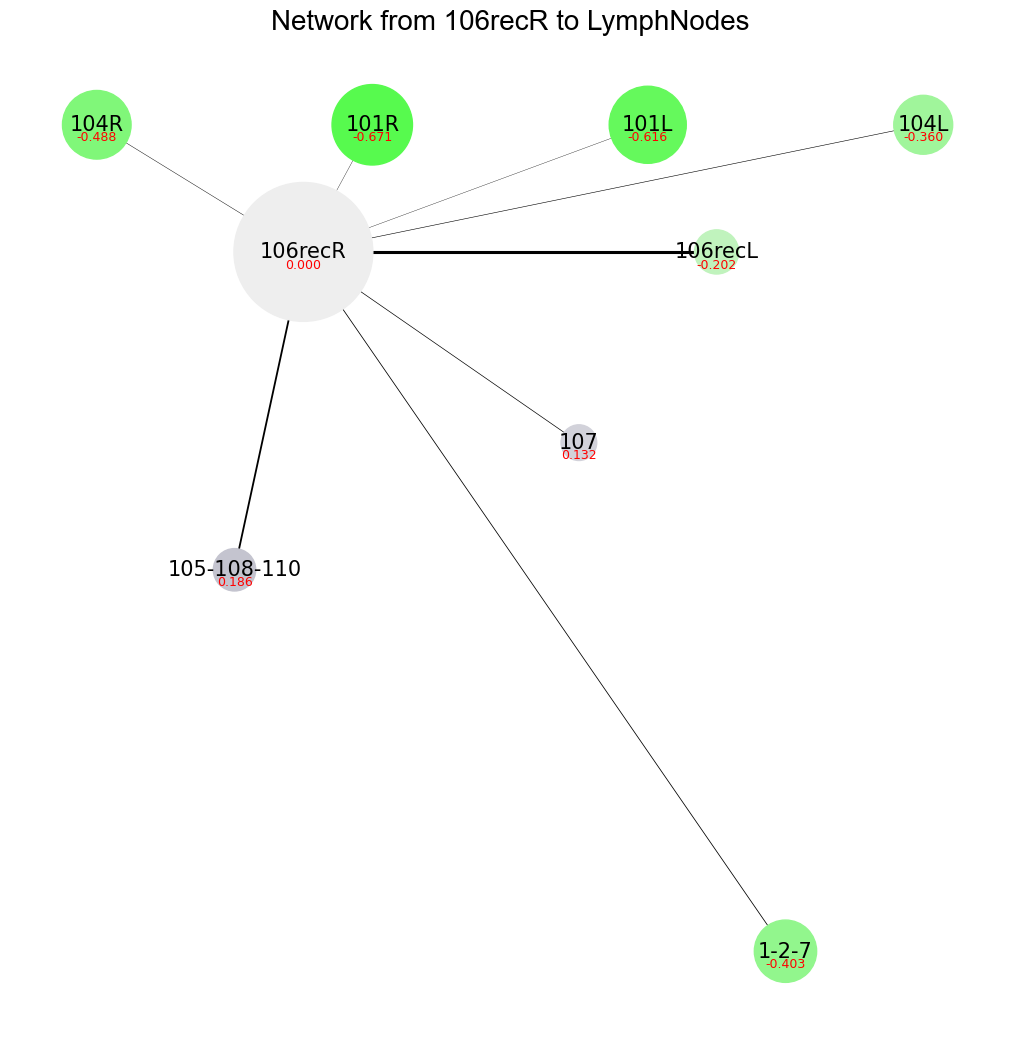

In [124]:
visualize_Network_TN_whole(df_106recR_Upper, '106recR', Lymphnode_Positions)

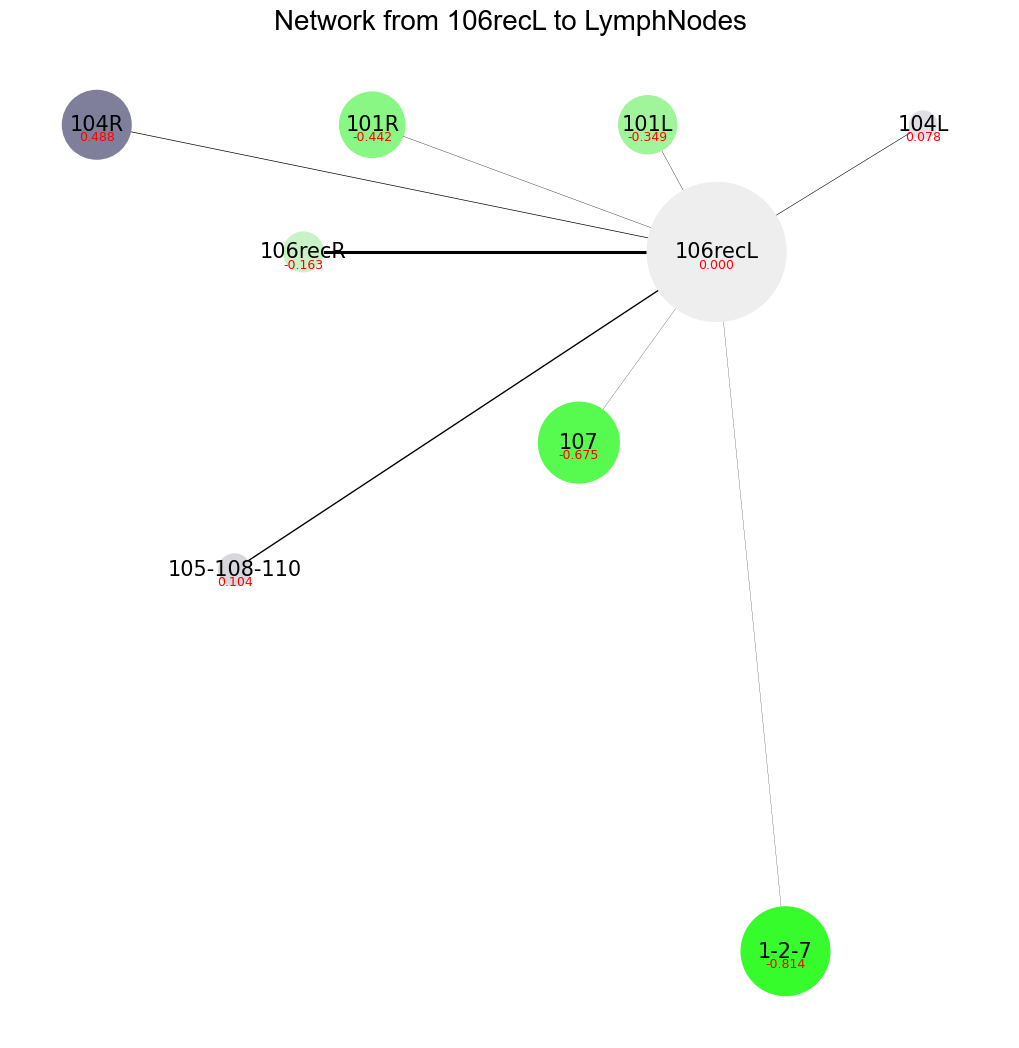

In [125]:
visualize_Network_TN_whole(df_106recL_Upper, '106recL', Lymphnode_Positions)

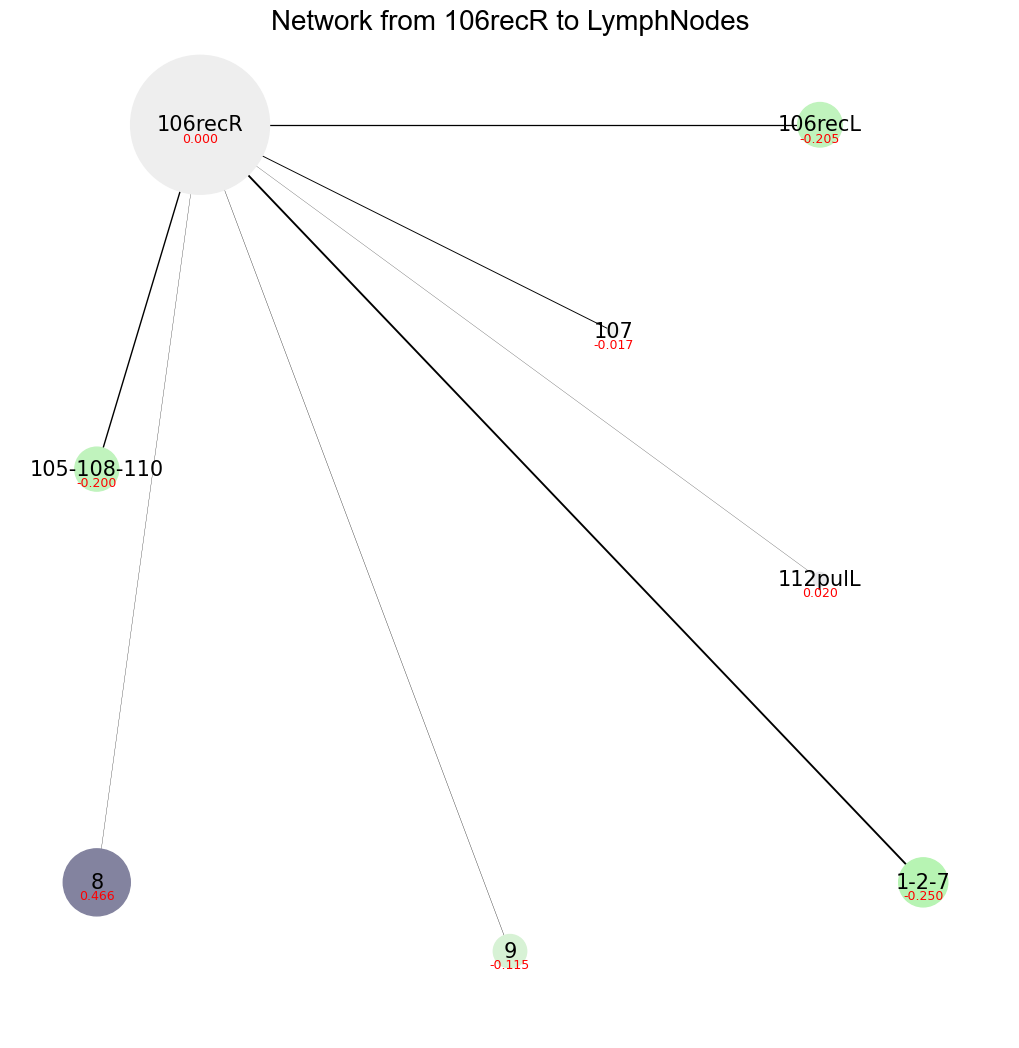

In [126]:
visualize_Network_TN_whole(df_106recR_Mid, '106recR', Lymphnode_Positions)

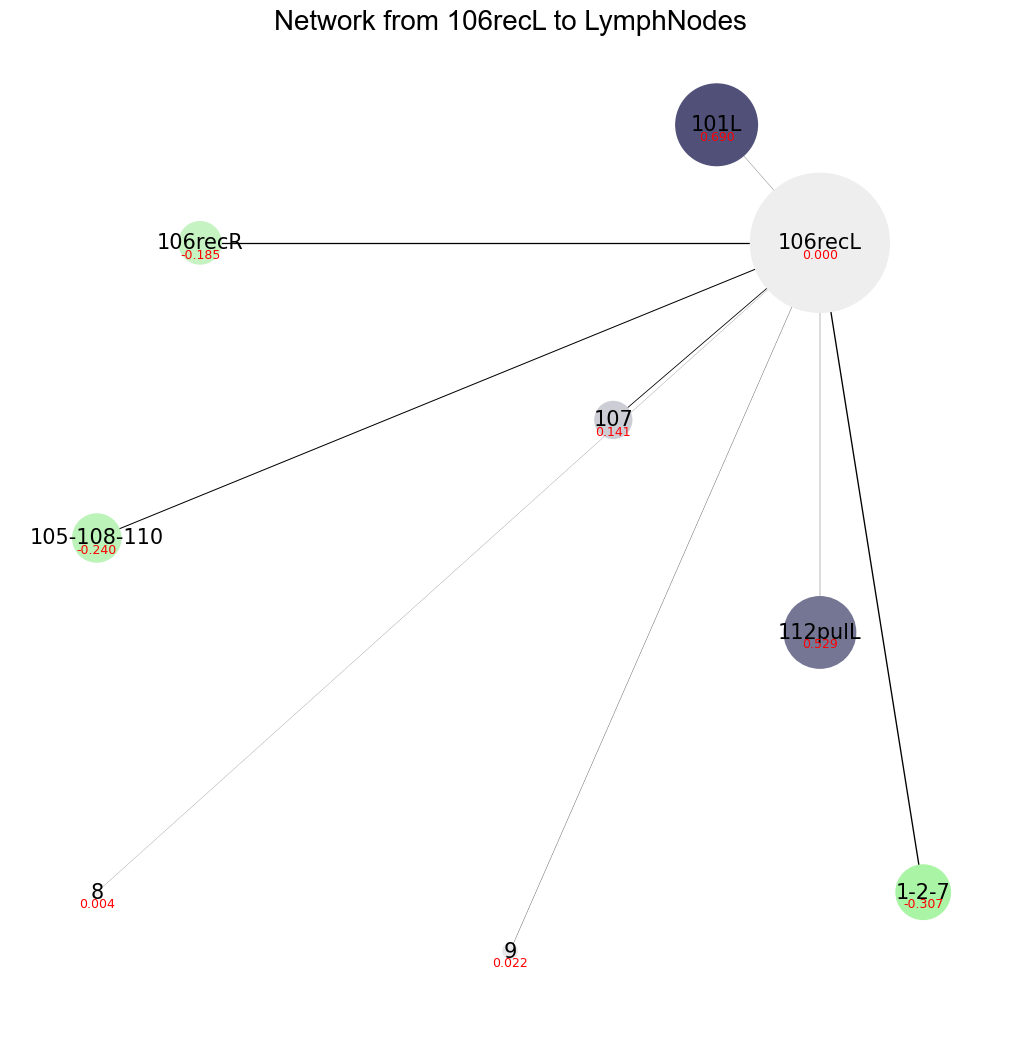

In [127]:
visualize_Network_TN_whole(df_106recL_Mid, '106recL', Lymphnode_Positions)

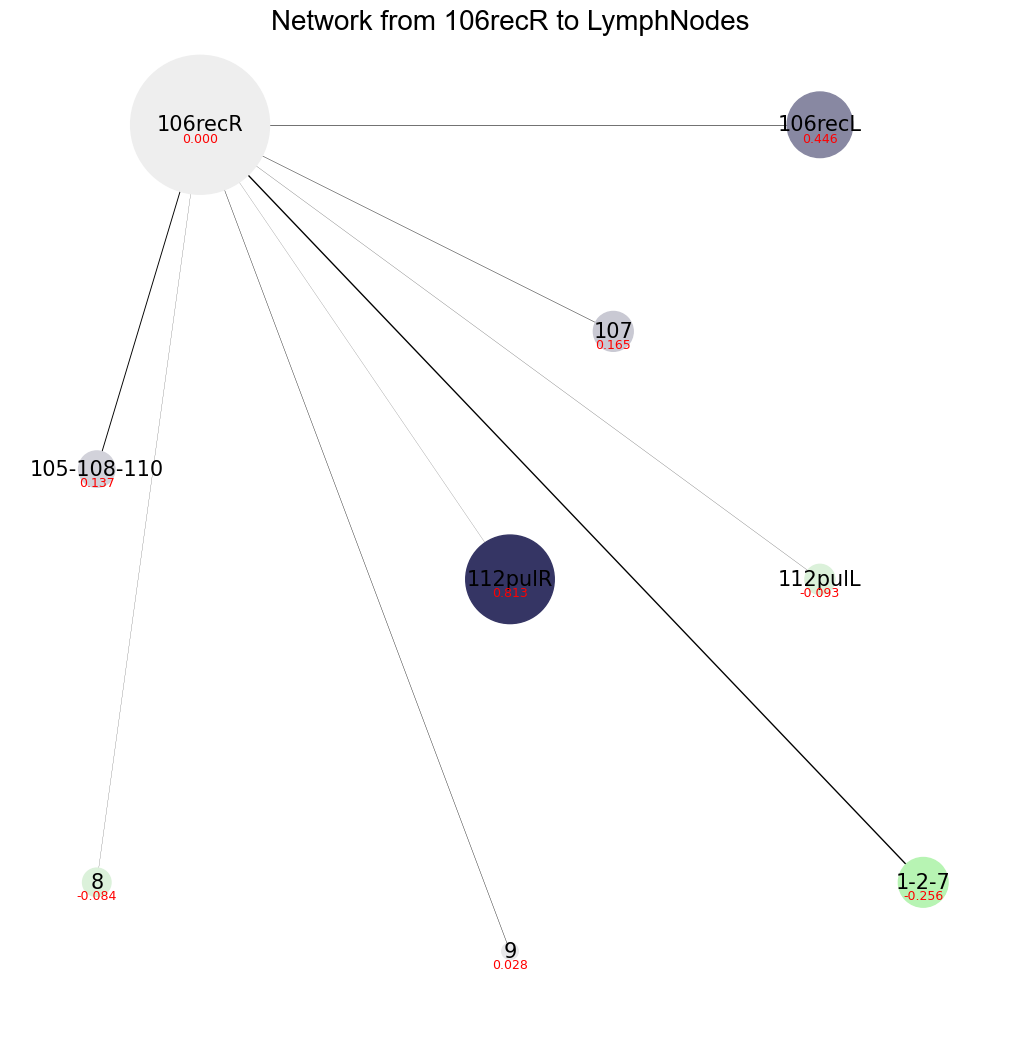

In [128]:
visualize_Network_TN_whole(df_106recR_Lower, '106recR', Lymphnode_Positions)

In [135]:
def visualize_Network_TN_subplot(edges_frequency, network_label, ax, Lymphnode_Positions):
    # Set the font to Arial
    plt.rcParams['font.family'] = 'Arial'
    
    G = nx.Graph()

    for index, row in edges_frequency.iterrows():
        G.add_edge(row['HubNodes'], row['LymphNode'], weight=row['support'])
        G.nodes[row['LymphNode']]['zhangs_metric'] = row['zhangs_metric']
    G.nodes[network_label.split()[0]]['zhangs_metric'] = 0  # Assign default value for hubNode

    # Prepare color and size maps
    edge_widths = [G[u][v]['weight'] * 10 for u, v in G.edges()]
    color_list = ['#0EFF00', '#F0F0F0', '#0B0B45']  # Light Green, Gray, Dark Blue
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    color_map = [G.nodes[node]['zhangs_metric'] for node in G.nodes()]
    
    # Adjust node sizes
    hubNode = network_label.split()[0]  # Extract the hub node from the label
    size_map = [10000 if node == hubNode else abs(G.nodes[node]['zhangs_metric']) * 5000 for node in G.nodes()]

    # Draw the graph on the specified axis
    nodes = nx.draw_networkx_nodes(G, Lymphnode_Positions, node_size=size_map, node_color=color_map, cmap=cmap, vmin=-1, vmax=1, ax=ax)
    nx.draw_networkx_edges(G, Lymphnode_Positions, width=edge_widths, ax=ax)
    nx.draw_networkx_labels(G, Lymphnode_Positions, font_size=15, font_color="black", ax=ax)
    
    # Round zhangs_metric values to 3 decimal places for labels
    zhangs_metric_labels = {node: f"{value:.3f}" for node, value in nx.get_node_attributes(G, 'zhangs_metric').items()}
    nx.draw_networkx_labels(G, Label_Positions, labels=zhangs_metric_labels, font_size=9, font_color='red', ax=ax)

    ax.set_title(network_label, fontsize=20)

    # Return the nodes for color mapping (needed for colorbar)
    return nodes

    
def plot_TN_specific_networks_2x2(hub_nodes, descriptors, lymphnode_positions, transformed_dataframes):
    plt.rcParams['font.family'] = 'Arial'
    
    fig, axs = plt.subplots(2, 2, figsize=(20, 20))
    axs = axs.flatten()
    ax_idx = 0

    for descriptor in descriptors:
        for hub_node in hub_nodes:
            ax = axs[ax_idx]
            df_name = f"df_{hub_node}_{descriptor}"
            
            if df_name in transformed_dataframes:
                edge_frequency_df = transformed_dataframes[df_name]
                nodes = visualize_Network_TN_subplot(edge_frequency_df, f"{hub_node} {descriptor}", ax, lymphnode_positions)

            ax_idx += 1

    plt.tight_layout()

    # Add colorbar
    fig.subplots_adjust(bottom=0.15)
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
    sm = plt.cm.ScalarMappable(cmap=nodes.cmap, norm=nodes.norm)
    fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label="Zhang's Metric")

    # Save and show figure
    save_path_svg = "../Results/Network_Analysis_Figure5.svg"
    fig.savefig(save_path_svg, format='svg', dpi=1200)
    
    save_path_png = "../Results/Network_Analysis_Figure5.png"
    fig.savefig(save_path_png, format='png', dpi=1200)
    
    plt.show()
    
    return save_path_svg, save_path_png

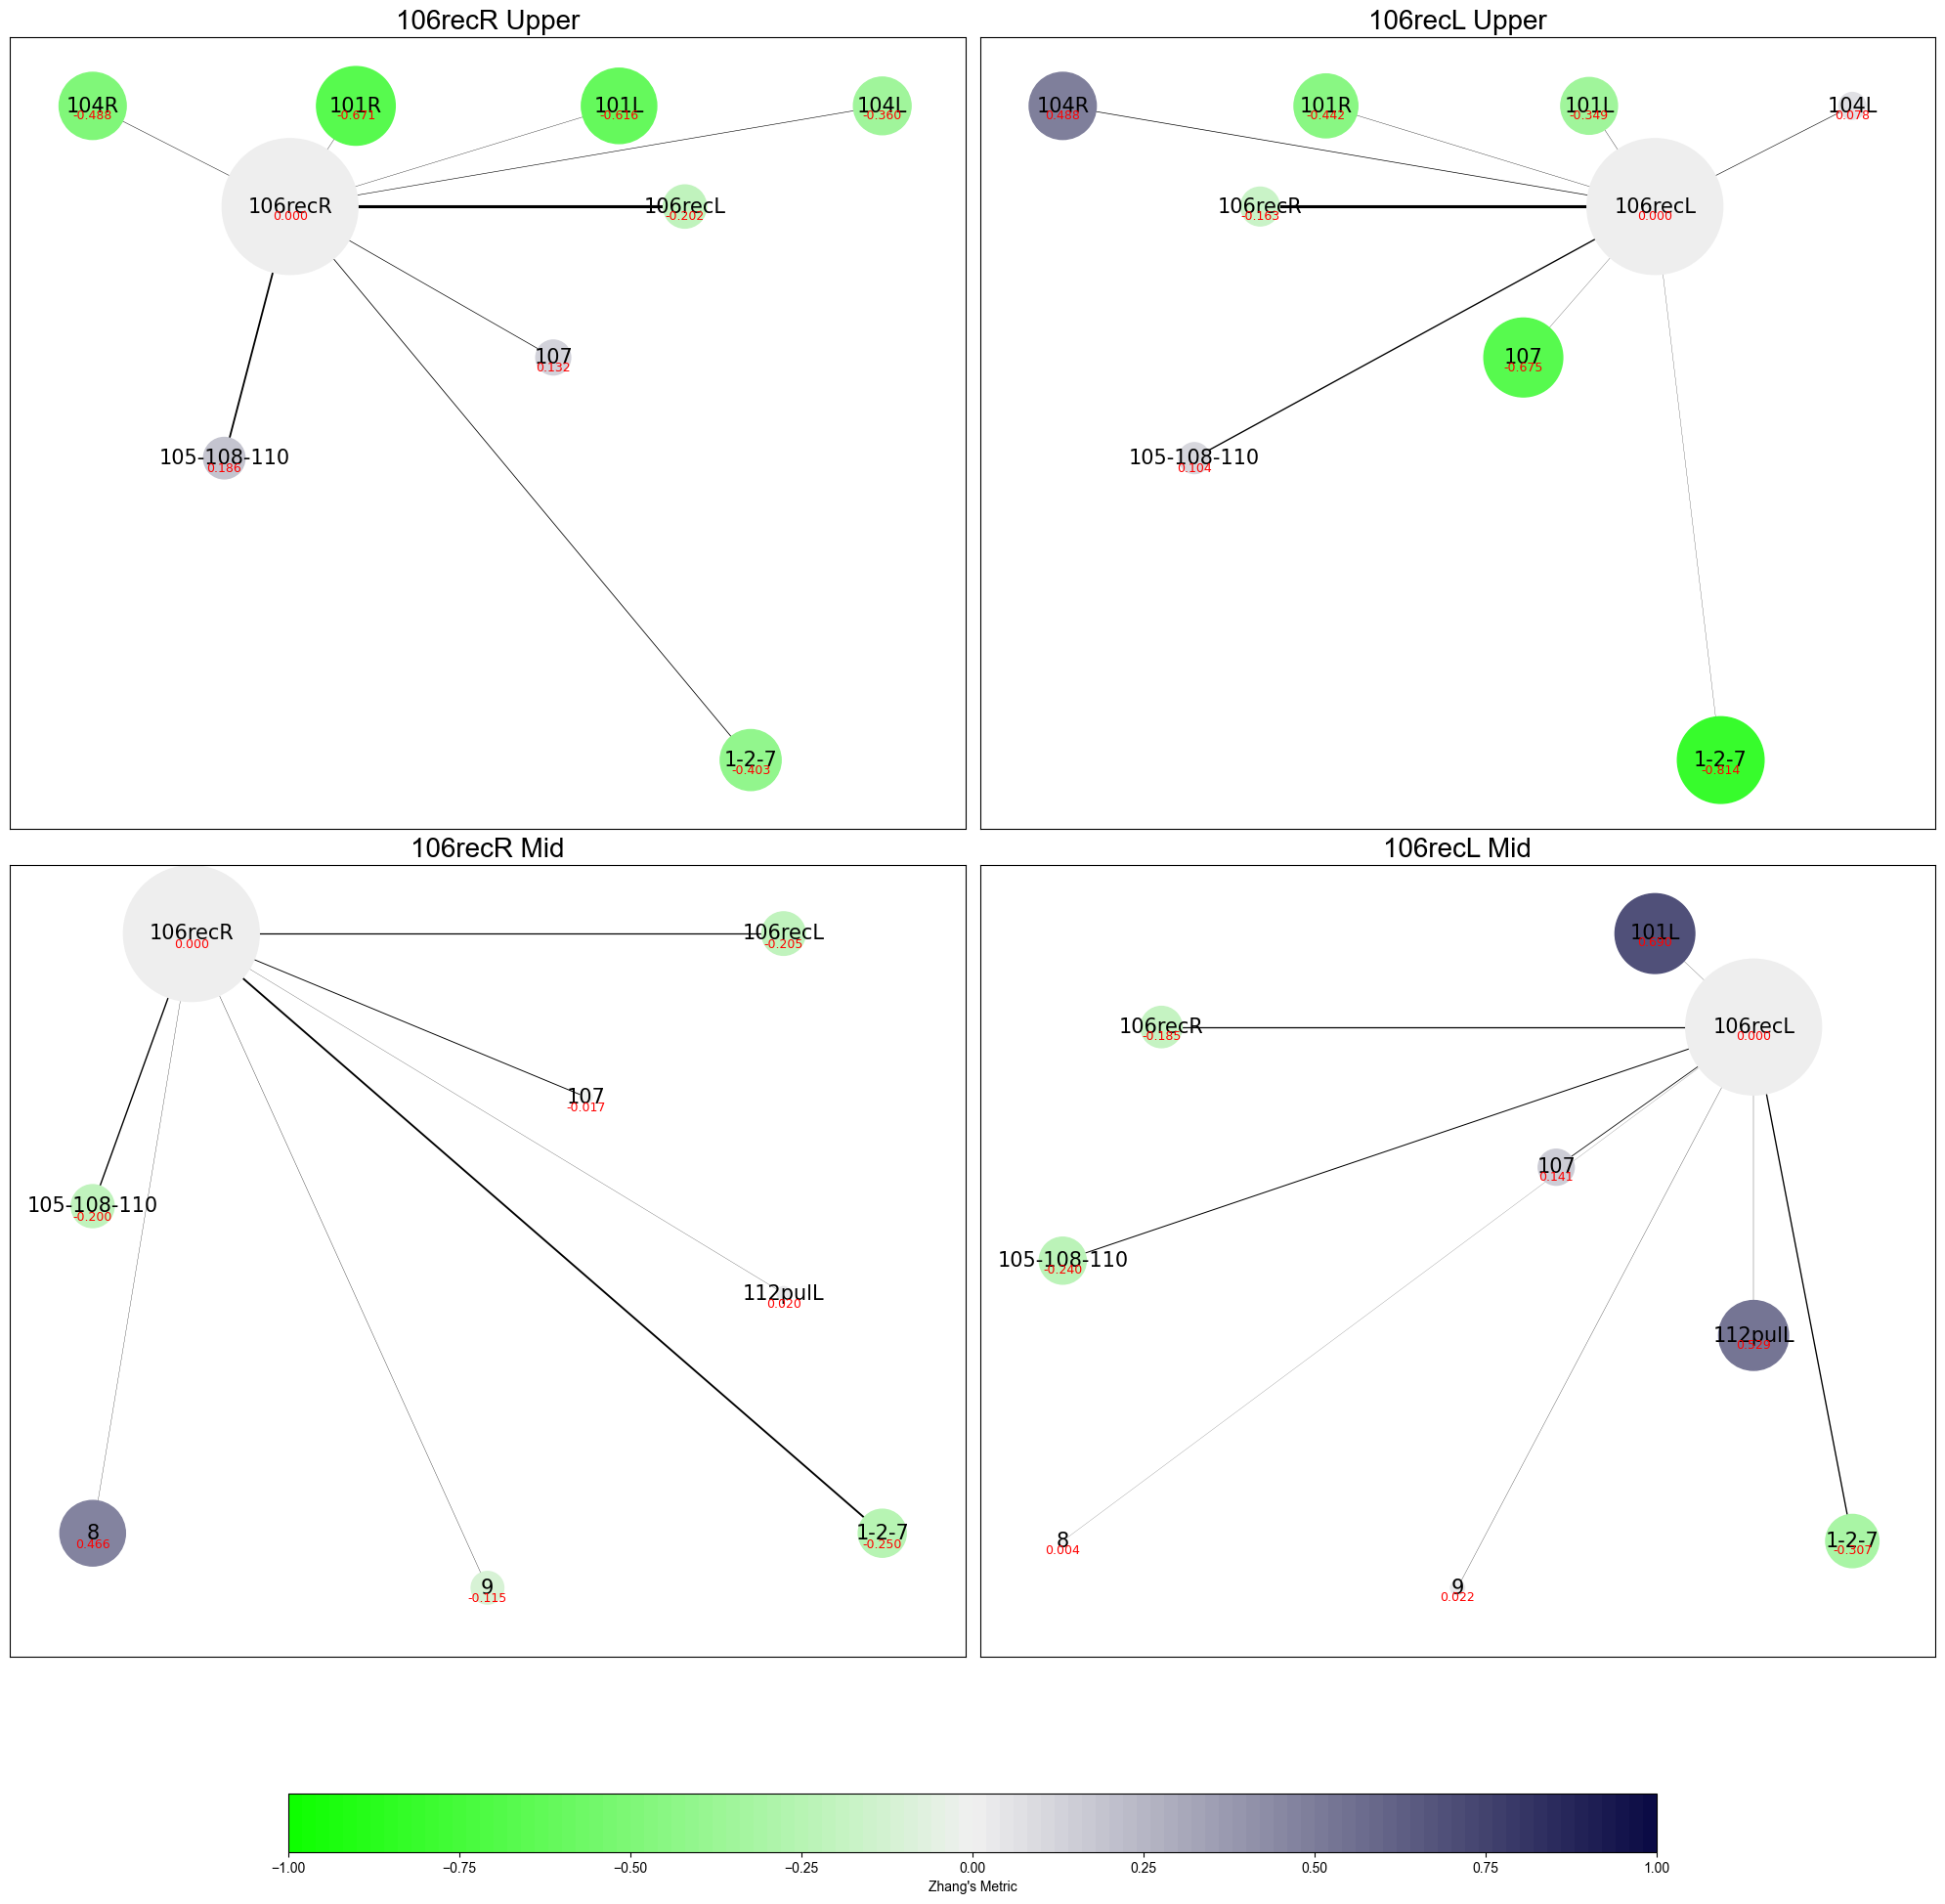

('../Results/Network_Analysis_Figure5.svg',
 '../Results/Network_Analysis_Figure5.png')

In [137]:
hub_nodes = ['106recR', '106recL']
descriptors = ['Upper', 'Mid']
transformed_dataframes = {
    'df_106recR_Upper': df_106recR_Upper,
    'df_106recR_Mid': df_106recR_Mid,
    'df_106recL_Upper': df_106recL_Upper,
    'df_106recL_Mid': df_106recL_Mid,
}

plot_TN_specific_networks_2x2(hub_nodes, descriptors, Lymphnode_Positions, transformed_dataframes)

In [96]:
transformed_TN_df_Whole_upper_all_ZM.to_csv('abc.csv')

### Plot multiple 2D Heatmaps with different confidence

In [97]:
def plot_multiple_transformed_heatmaps_TN_confidence(dfs_TN, dfs_opposite_TN, names, title):
    """
    Generate multiple heatmaps using a list of transformed DataFrames.
    
    Parameters:
    dfs (list): List of transformed DataFrames suitable for heatmap plotting
    names (list): List of names for the heatmap titles
    """
    # Predefined order of the lymph nodes
    predefined_order = ['101R', '101L', '102R', '102L', '104R', '104L', '106preR', '106preL', '106recR', 
                        '106recL', '107', '105-108-110', '112pulR', '112pulL', '1-2-7', '8', '9']

    plt.figure(figsize=(15, 8 * len(dfs_TN)))
    
    vmin_val, vmax_val = -1, 1
    color_list = ['#0EFF00', '#F0F0F0', '#0B0B45']  # Green, Gray, Blue
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    all_unique_lymph_nodes = set()
    
    for df in dfs_TN:
        unique_lymph_nodes = df['LymphNode'].unique()
        all_unique_lymph_nodes.update(unique_lymph_nodes)
    
    for i, (df_TN, df_opposite, name) in enumerate(zip(dfs_TN, dfs_opposite_TN, names)):
        plt.subplot(len(dfs_TN), 1, i + 1)
        unique_hub_nodes = df_TN['HubNodes'].unique()

        nodes_sorted_first = [node for node in unique_hub_nodes if node in all_unique_lymph_nodes]
        remaining_nodes = [node for node in predefined_order if node not in nodes_sorted_first and node in all_unique_lymph_nodes]
        all_nodes_sorted = nodes_sorted_first + remaining_nodes
        
        heatmap_data = pd.DataFrame(index=unique_hub_nodes, columns=all_nodes_sorted)

        # Net confidence calculation
        for _, row in df_TN.iterrows():
            hub = row['HubNodes']
            lymph = row['LymphNode']
            confidence = row['Confidence']

            opposite_row = df_opposite[(df_opposite['LymphNode'] == lymph) & (df_opposite['HubNodes'] == hub)]
    
            if not opposite_row.empty:
                opposite_confidence = opposite_row.iloc[0]['Confidence']
                net_confidence = confidence - opposite_confidence
            else:
                net_confidence = confidence

            heatmap_data.at[hub, lymph] = net_confidence
            
        heatmap_data = heatmap_data.astype(float)
        heatmap_data.fillna(0, inplace=True)
        
        if heatmap_data.shape[0] == 1 or heatmap_data.shape[1] == 1:
            ax = sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'}, vmin=vmin_val, vmax=vmax_val, cbar=False)
        else:
            ax = sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'}, vmin=vmin_val, vmax=vmax_val)
        
        # Only erase the values if values are below 0.02
        for text in ax.texts:
            text_str = text.get_text()
            if text_str and -0.05 < float(text_str) < 0.05:
                text.set_text('')
                
        ax.axvline(x=len(unique_hub_nodes), color='black', linewidth=1.5)

        cbar = ax.collections[0].colorbar
        cbar.ax.set_ylabel('Confidence Value', size=14)
        
        plt.title(f'LN Metastasis Heatmap for {name}', fontsize=16)
        plt.xlabel('Specific LN Stations', fontsize=14)
        plt.ylabel('Hub LN Stations', fontsize=14)
    
    plt.tight_layout()
    save_path = f"../Results/2D_Heatmap_TN_{title}.png"
    plt.savefig(save_path)
    plt.show()

In [98]:
# transformed_TN_df_T1_upper_C_all, transformed_TN_df_T24_upper_C_all = transform_for_heatmap_TN('T1_upper', 'T24_upper', 'all', 'Confidence', 4)
# transformed_TN_df_T1_mid_C_all, transformed_TN_df_T24_mid_C_all = transform_for_heatmap_TN('T1_mid', 'T24_mid', 'all', 'Confidence', 5)
# transformed_TN_df_T1_lower_C_all, transformed_TN_df_T24_lower_C_all = transform_for_heatmap_TN('T1_lower', 'T24_lower', 'all', 'Confidence', 4)

# transformed_TN_df_T1_upper_O_C_all, transformed_TN_df_T24_upper_O_C_all = transform_for_heatmap_opposite_TN('T1_upper', 'T24_upper', 'all', 'Confidence', 4)
# transformed_TN_df_T1_mid_O_C_all, transformed_TN_df_T24_mid_O_C_all = transform_for_heatmap_opposite_TN('T1_mid', 'T24_mid', 'all', 'Confidence', 5)
# transformed_TN_df_T1_lower_O_C_all, transformed_TN_df_T24_lower_O_C_all = transform_for_heatmap_opposite_TN('T1_lower', 'T24_lower', 'all', 'Confidence', 4)

In [ ]:
# Create the multiple heatmaps (Difference in Confidence) 
# plot_multiple_transformed_heatmaps_TN_confidence([transformed_TN_df_T1_upper_C_all, transformed_TN_df_T24_upper_C_all], [transformed_TN_df_T1_upper_O_C_all, transformed_TN_df_T24_upper_O_C_all], ['T1_upper', 'T24_upper'], 'upper_Confidence')

In [ ]:
# Create the multiple heatmaps (Difference in Confidence) 
# plot_multiple_transformed_heatmaps_TN_confidence([transformed_TN_df_T1_mid_C_all, transformed_TN_df_T24_mid_C_all], [transformed_TN_df_T1_mid_O_C_all, transformed_TN_df_T24_mid_O_C_all], ['T1_mid', 'T24_mid'], 'mid_Confidence')

In [ ]:
# Create the multiple heatmaps (Difference in Confidence) 
# plot_multiple_transformed_heatmaps_TN_confidence([transformed_TN_df_T1_lower_C_all, transformed_TN_df_T24_lower_C_all], [transformed_TN_df_T1_lower_O_C_all, transformed_TN_df_T24_lower_O_C_all], ['T1_lower', 'T24_lower'], 'lower_Confidence')